# Set up

In [2]:
!pip install matplotlib
!pip install numpy
!pip install pandas
!pip install seaborn
!pip install scikit-learn
!pip install tensorflow
!pip install lazypredict

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 1.9 MB/s eta 0:00:00


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [4]:
 # data reading
df = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/Apziva/term-deposit-marketing-2020.csv')

# EDA

### Data Information

In [5]:
# quick look at the data

print('Data shape:')
print(df.shape)
print('\nData head:')
print(df.head())
print('\nData info:')
print(df.info())
print('\nData description:')
print(df.describe(include='all'))
print('\nNull values:')
print(df.isnull().sum())
print('\n"unknown" values:')
print(df.apply(lambda x: (x == 'unknown').sum()))

Data shape:
(40000, 14)

Data head:
   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign   y  
0  unknown    5   may       261         1  no  
1  unknown    5   may       151         1  no  
2  unknown    5   may        76         1  no  
3  unknown    5   may        92         1  no  
4  unknown    5   may       198         1  no  

Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        40000 non-null  

### Target Value (Y)

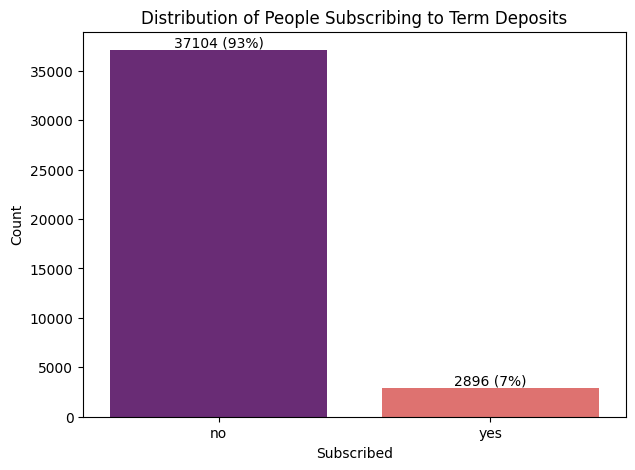

In [6]:
plt.figure(figsize=(7, 5))
ax = sns.countplot(x='y', data=df, palette='magma')
plt.title('Distribution of People Subscribing to Term Deposits')
plt.xlabel('Subscribed')
plt.ylabel('Count')

# get counts and percentages
abs_values = df['y'].value_counts(ascending=False)
rel_values = df['y'].value_counts(ascending=False, normalize=True).values * 100
labels = [f'{p[0]} ({p[1]:.0f}%)' for p in zip(abs_values, rel_values)]

# Add labels to the bars using ax.annotate
for i, p in enumerate(ax.patches):
    ax.annotate(labels[i], (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

### Categorical features

In [7]:
sns.color_palette('magma')

[(0.135053, 0.068391, 0.315),
 (0.372116, 0.092816, 0.499053),
 (0.594508, 0.175701, 0.501241),
 (0.828886, 0.262229, 0.430644),
 (0.973381, 0.46152, 0.361965),
 (0.997341, 0.733545, 0.505167)]

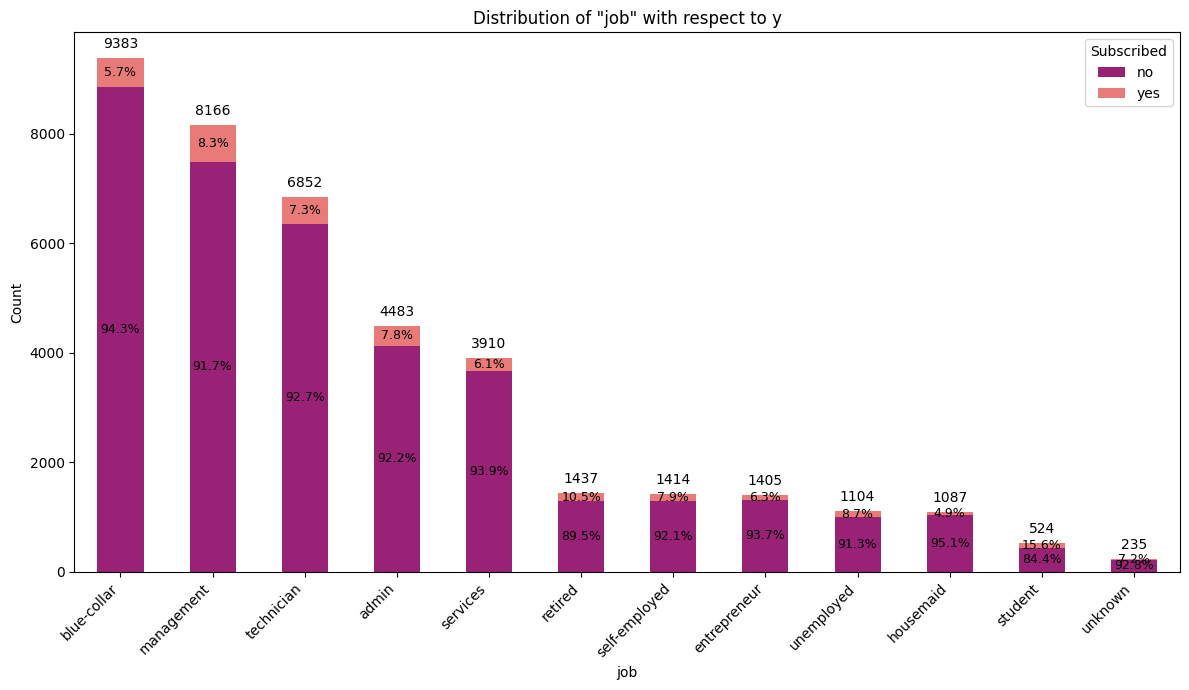

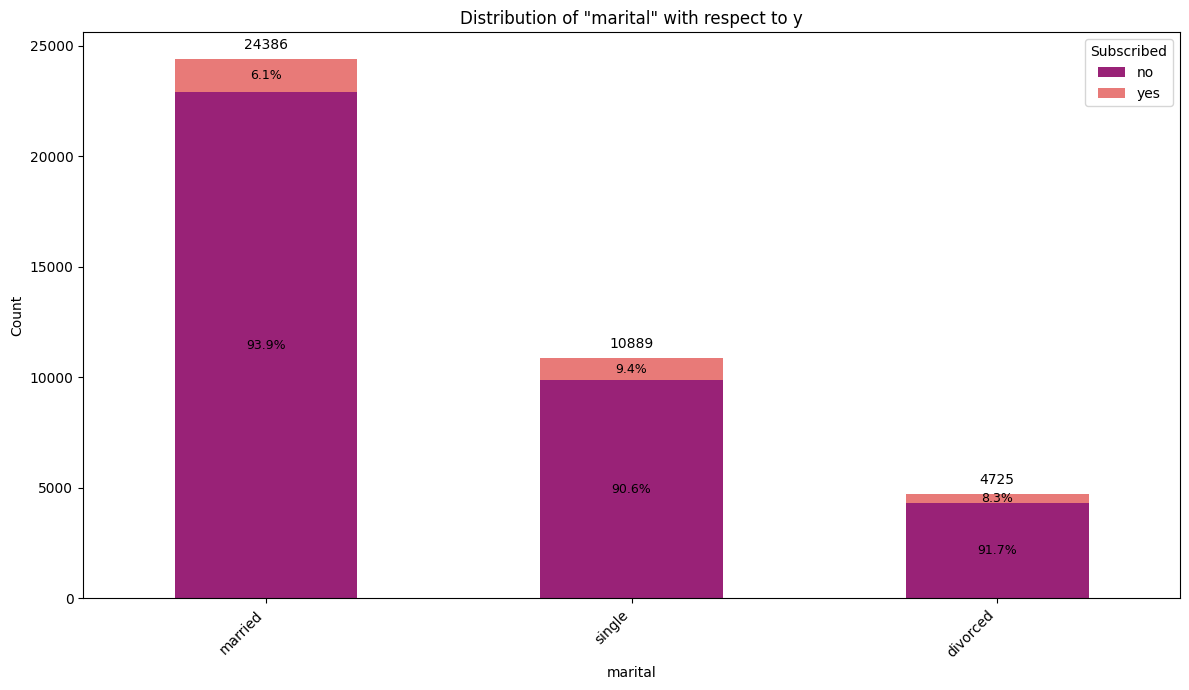

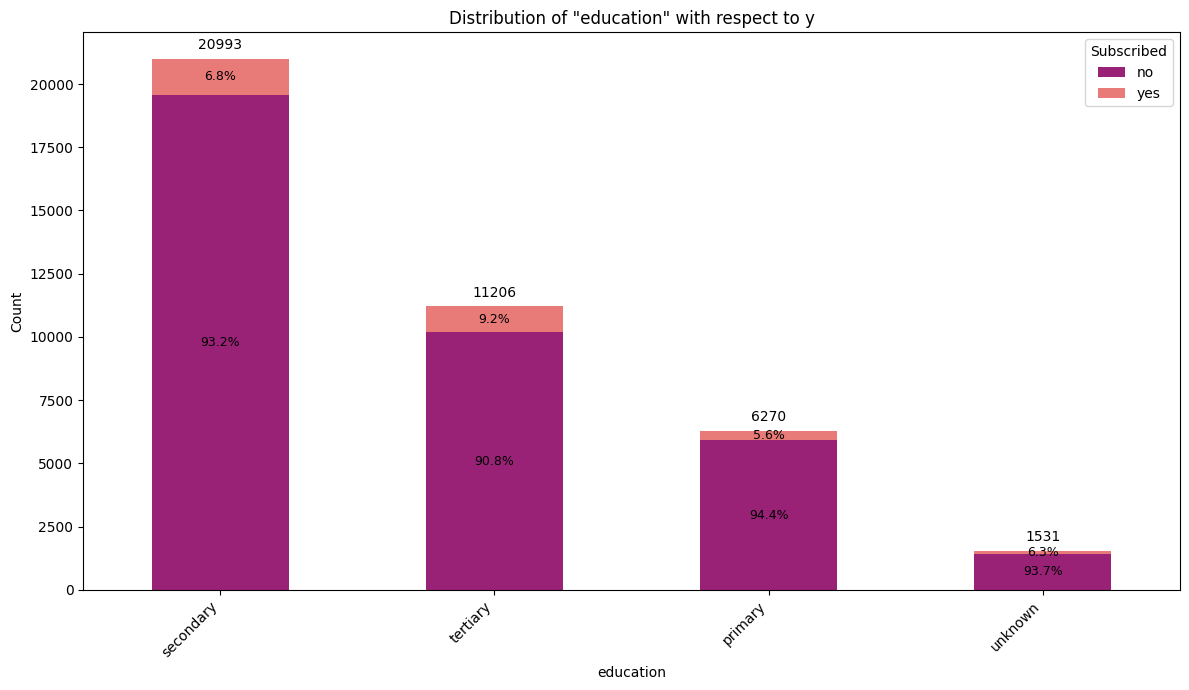

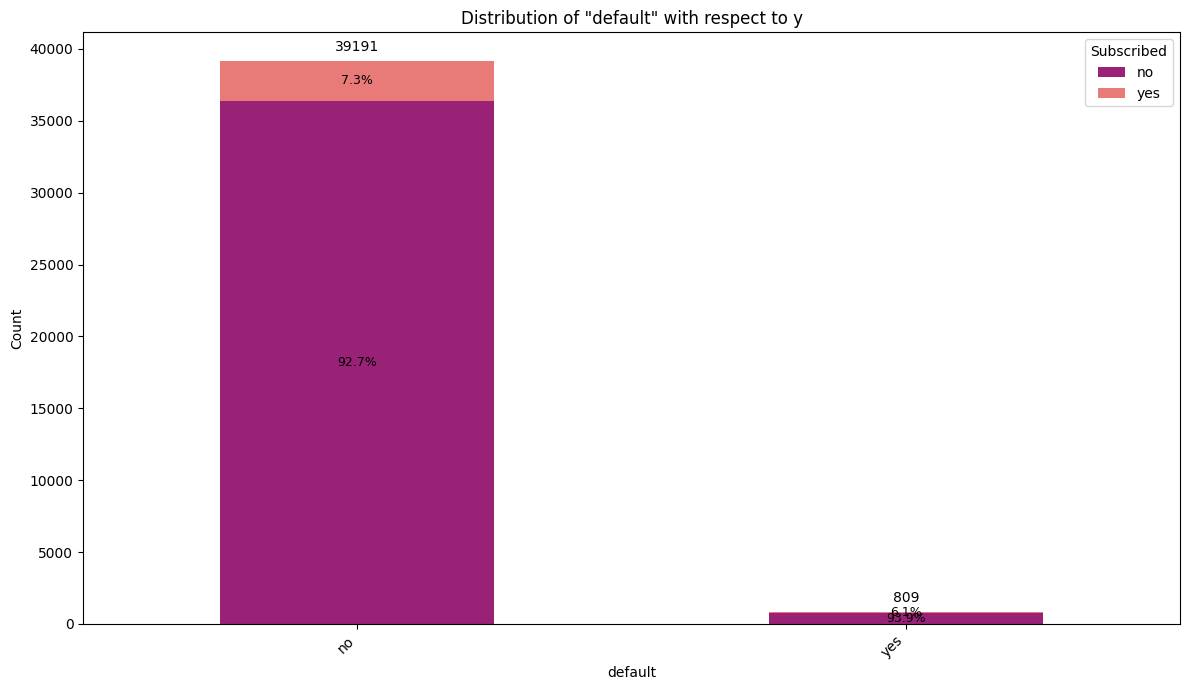

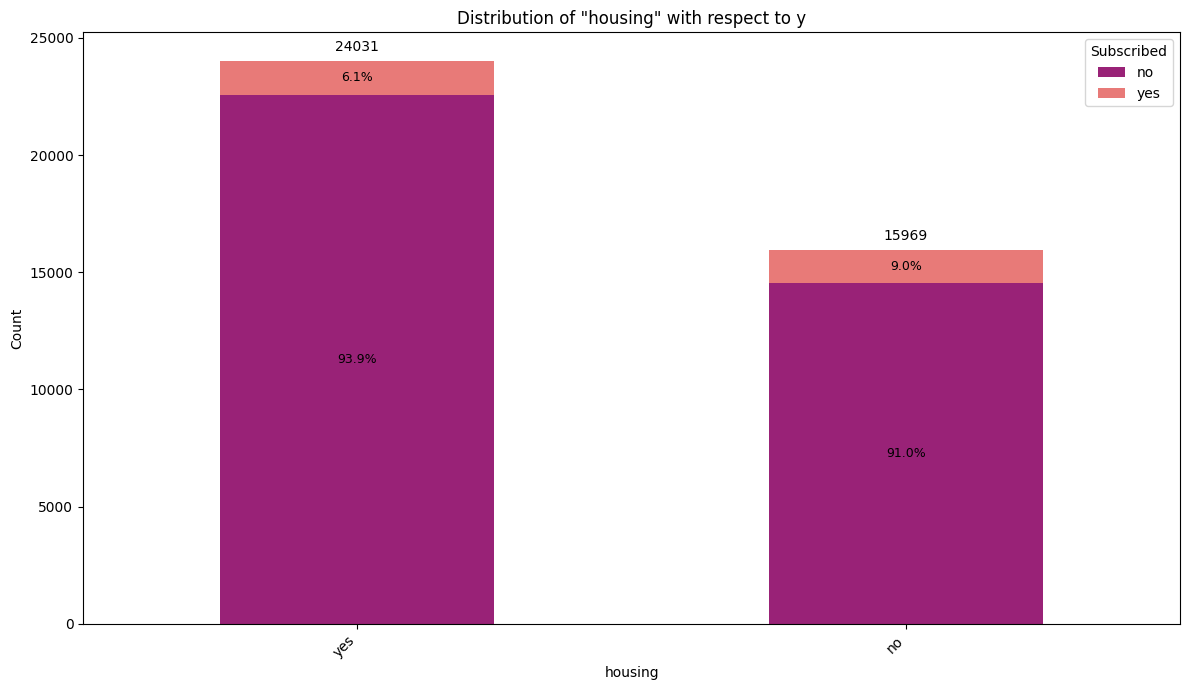

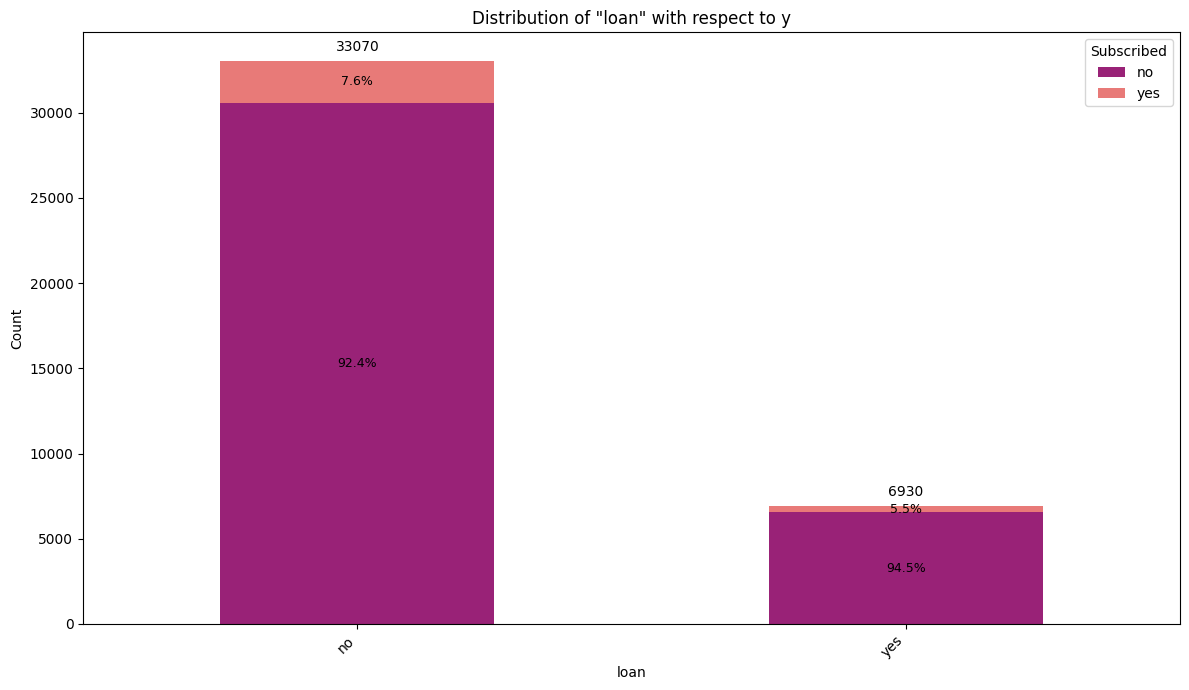

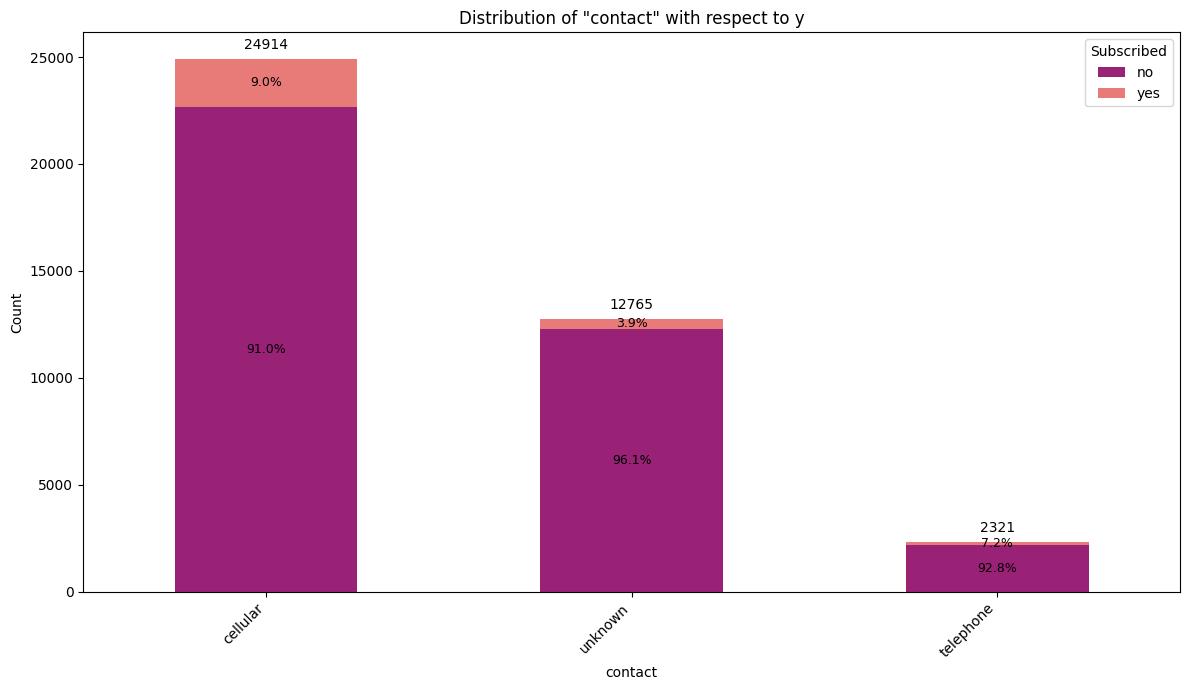

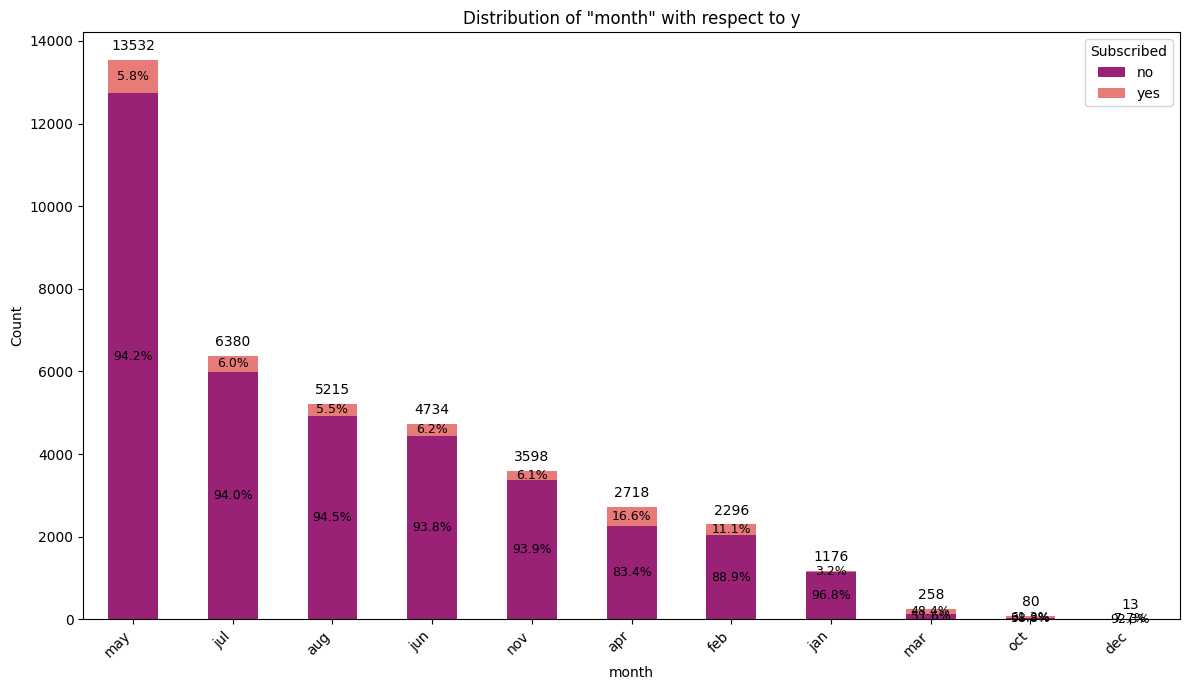

In [8]:
# Quick look at CATEGORICAL FEATURES

categorical_cols = df.select_dtypes(include='object').columns.tolist()
if 'y' in categorical_cols:
    categorical_cols.remove('y')

for col in categorical_cols:
    plt.figure(figsize=(12, 7))

    # Create a crosstab to get counts of 'yes' and 'no' for each category
    crosstab_df = pd.crosstab(df[col], df['y'], normalize=False)

    # Ensure 'no' and 'yes' columns exist, even if one is empty for a category
    if 'no' not in crosstab_df.columns: crosstab_df['no'] = 0
    if 'yes' not in crosstab_df.columns: crosstab_df['yes'] = 0

    # Reorder columns to ensure 'no' is below 'yes' if that's the desired stacking order
    crosstab_df = crosstab_df[['no', 'yes']]

    # Sort categories by total count (sum of 'no' and 'yes') for better visualization
    crosstab_df['total'] = crosstab_df.sum(axis=1)
    crosstab_df = crosstab_df.sort_values(by='total', ascending=False)

    # Plot as a stacked bar chart
    ax = crosstab_df.drop('total', axis=1).plot(kind='bar', stacked=True, color=['#992277', '#e87a78'], ax=plt.gca())

    plt.title(f'Distribution of "{col}" with respect to y')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Subscribed')

    # Add labels to each section of the stacked bars (percentages)
    for container_idx, container in enumerate(ax.containers):
        for patch_idx, patch in enumerate(container.patches):
            height = patch.get_height()
            x, y = patch.get_xy()
            width = patch.get_width()

            if height > 0: # Only label if there is a bar segment
                # The x-category name corresponding to this patch
                x_category = crosstab_df.index[patch_idx]

                # Total height of the stacked bar for this x_category
                total_of_stacked_bar = crosstab_df.loc[x_category, 'total']

                if total_of_stacked_bar > 0:
                    percentage = (height / total_of_stacked_bar) * 100
                    label_text = f'{percentage:.1f}%'
                else:
                    label_text = '' # Hide label if segment height is 0

                # Position the label in the center of the bar segment
                ax.annotate(label_text,
                            (x + width / 2., y + height / 2.),
                            ha='center', va='center', fontsize=9, color='black')

    # Add total counts at the top of the stacked bars
    for i, (category, total_value) in enumerate(crosstab_df['total'].items()):
        # Find the x-position for the top of this stacked bar
        # Use the x-position of the 'no' bar segment (container_idx=0) for this category
        if i < len(ax.containers[0].patches):
            x_center = ax.containers[0].patches[i].get_x() + ax.containers[0].patches[i].get_width() / 2.

            # Place the total value label slightly above the stacked bar
            ax.annotate(f'{int(total_value)}',
                        (x_center, total_value), # x at center of bar, y at top of bar
                        ha='center', va='bottom', fontsize=10, color='black',
                        xytext=(0, 5), # Offset text slightly above the bar
                        textcoords='offset points')

    plt.tight_layout()
    plt.show()

#### Subscribers analysis
X-axis is in the same order as the main dataset

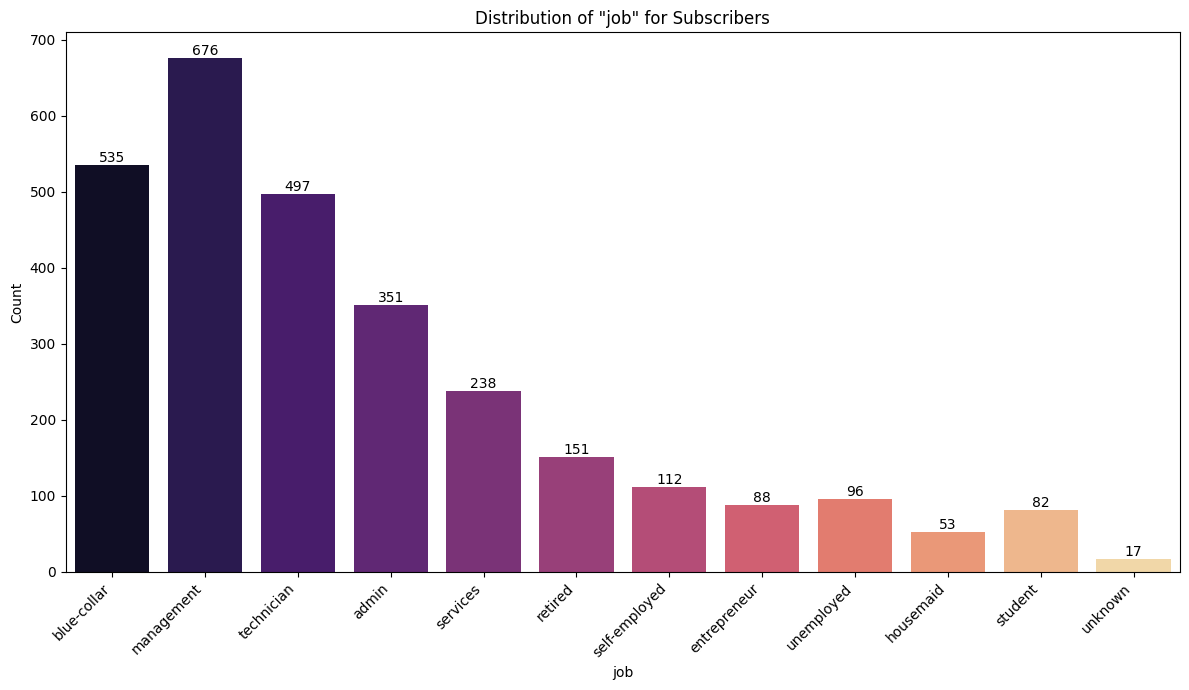

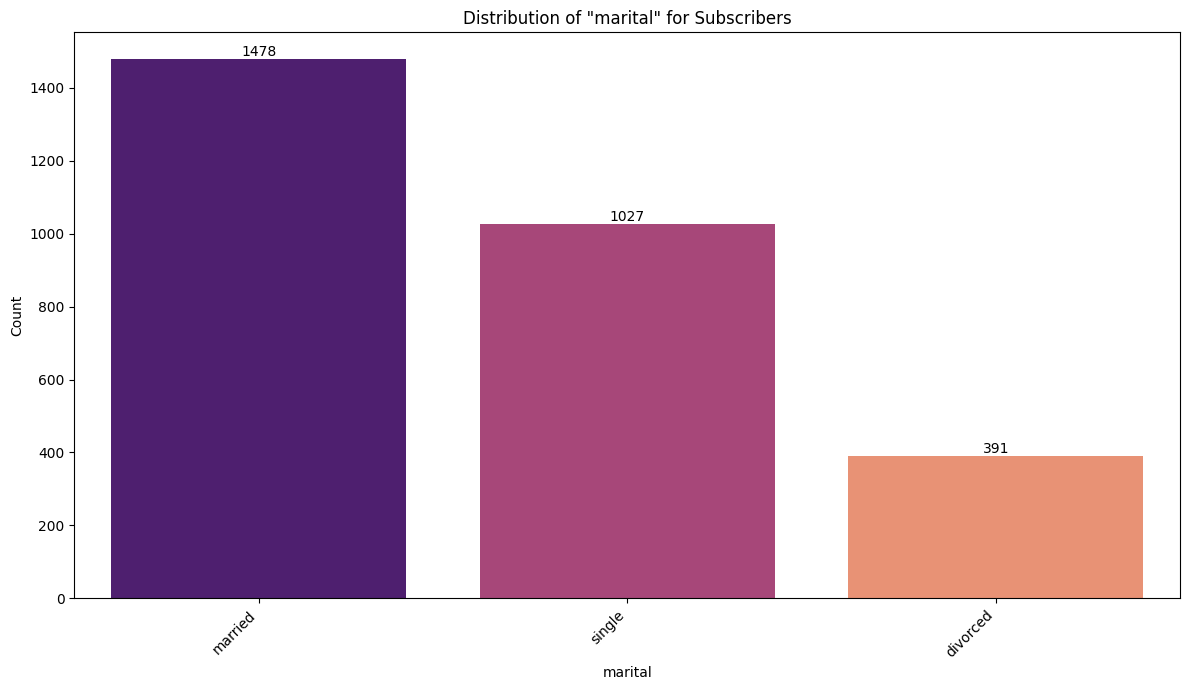

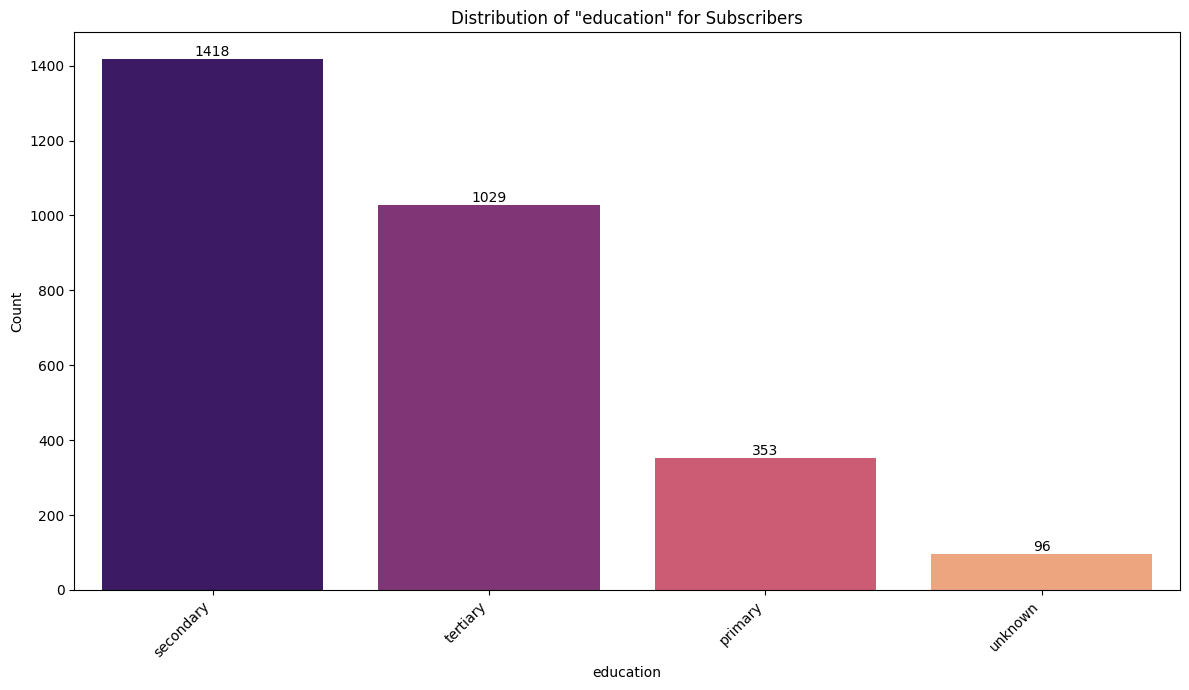

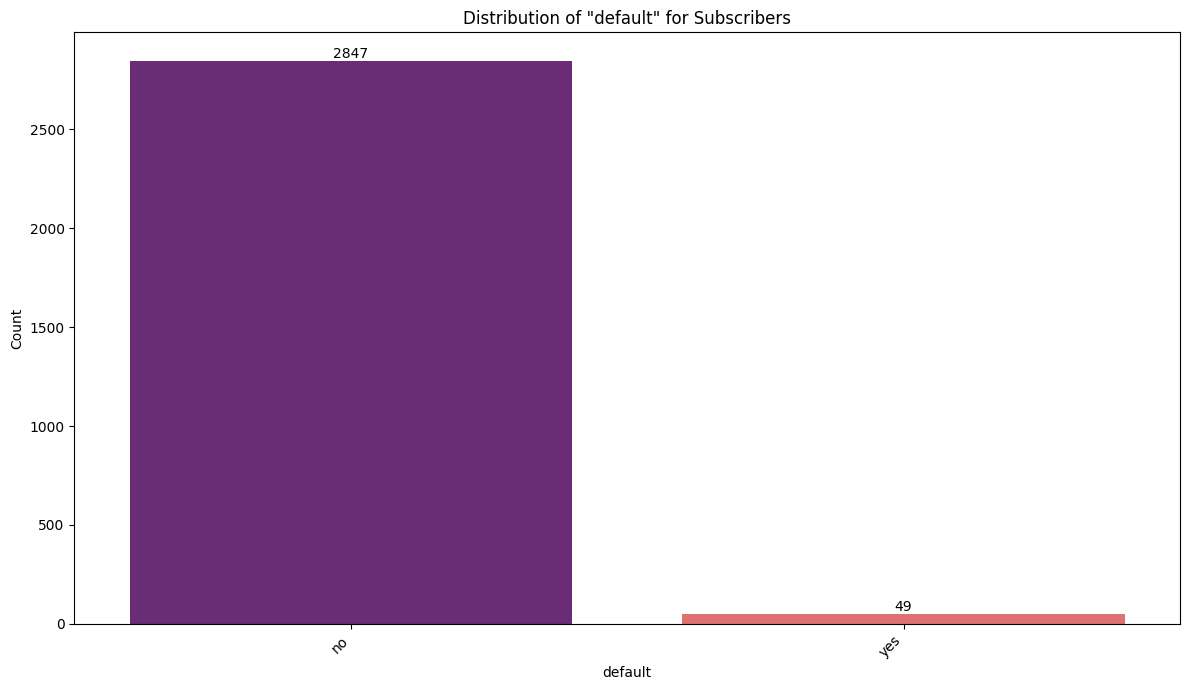

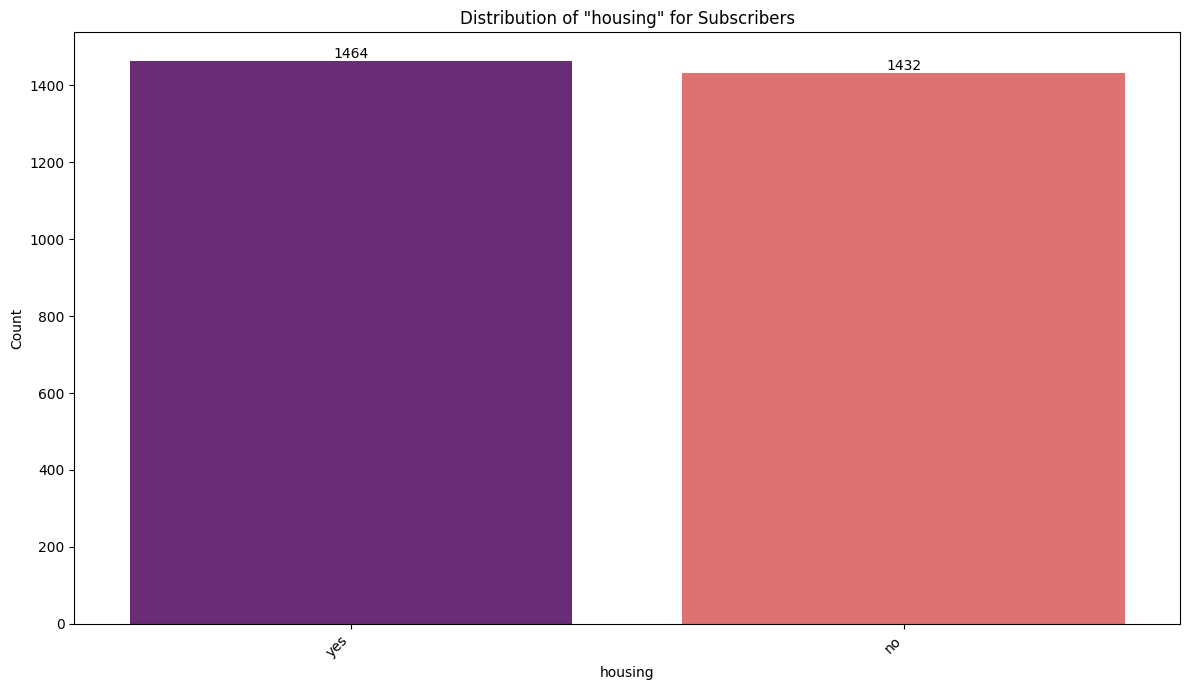

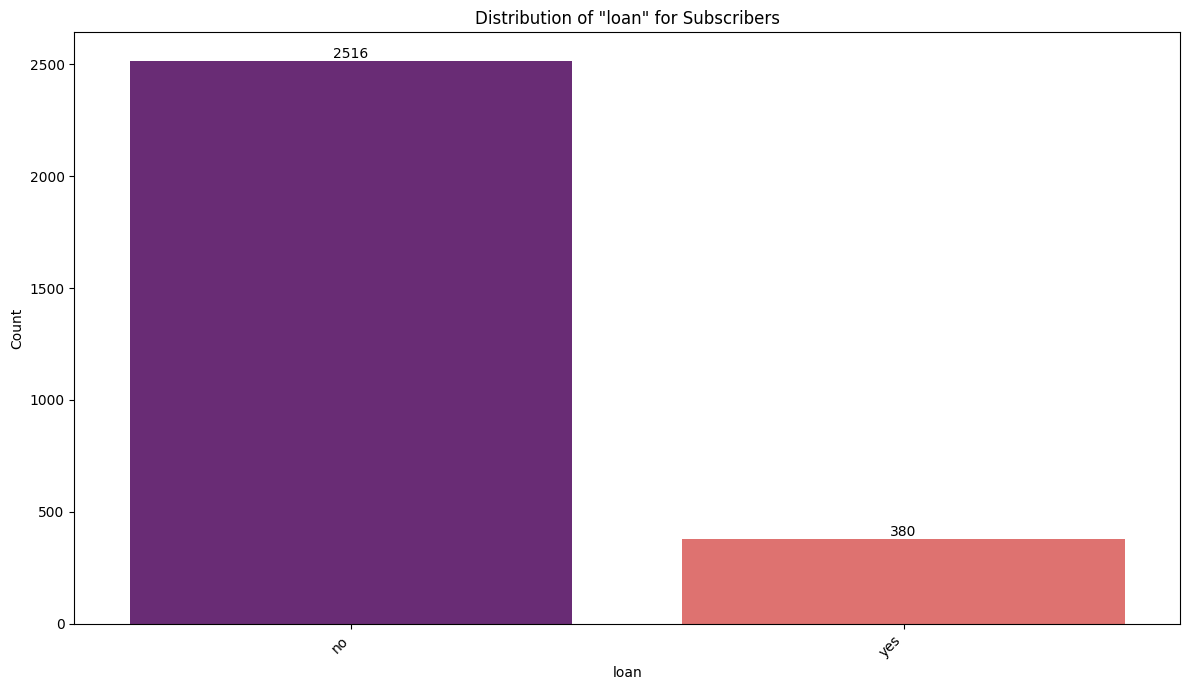

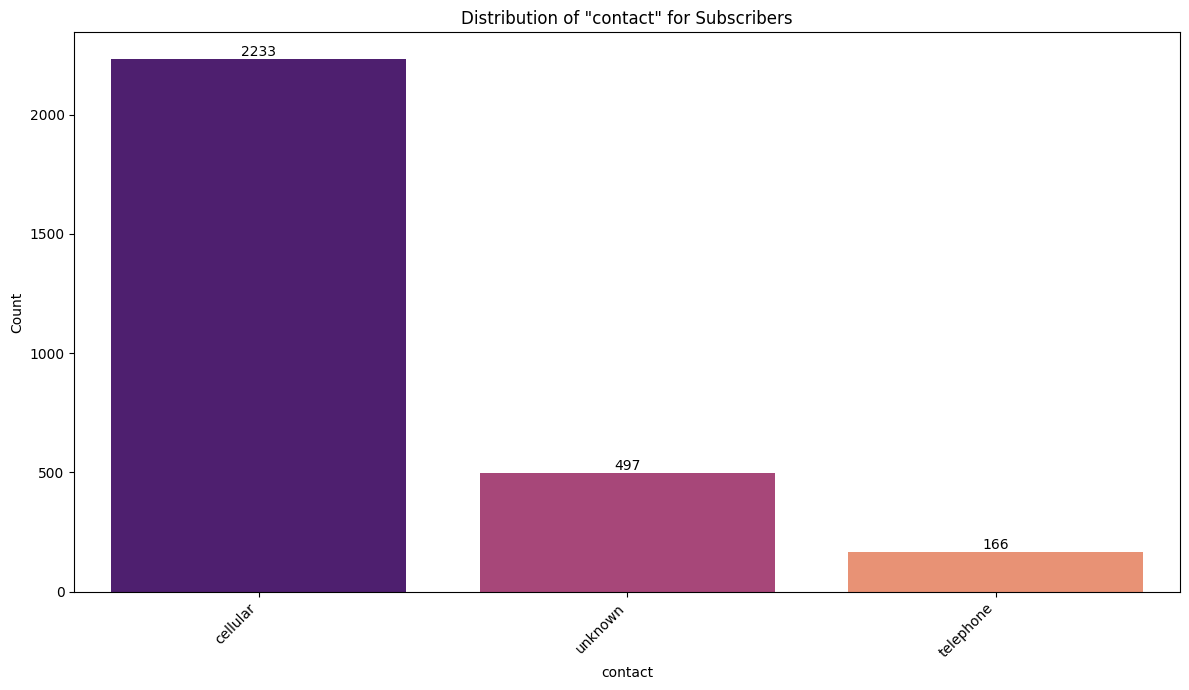

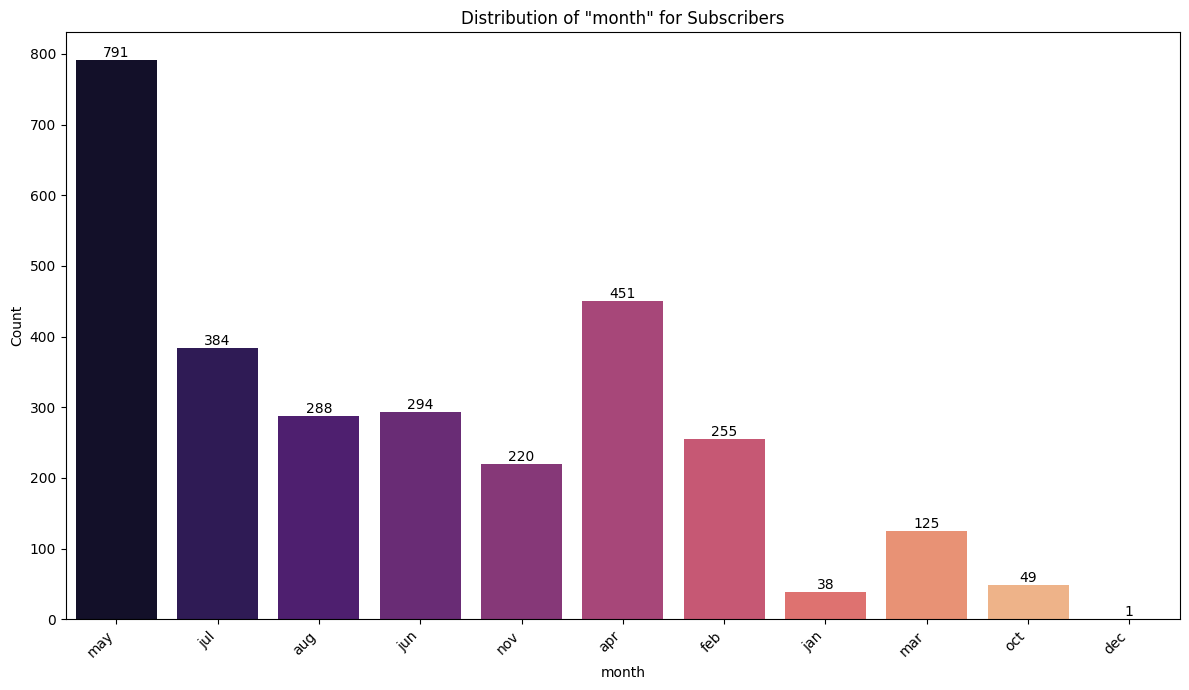

In [9]:
df_subs = df[df['y']=='yes']

for col in categorical_cols:
    plt.figure(figsize=(12, 7))
    ax = sns.countplot(x=col, data=df_subs, order=df[col].value_counts(ascending=False).index,palette='magma')
    plt.title(f'Distribution of "{col}" for Subscribers')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')

    # Add total counts at the top of the bars
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', label_type='edge')

    plt.tight_layout()
    plt.show()

note april and march

### Numerical features
start by encoding y and month

In [10]:
#encode month
df_encoded = df.copy()
df_encoded['month_encoded'] = df_encoded['month'].str.lower().map({
    'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4, 'may': 5, 'jun': 6,
    'jul': 7, 'aug': 8, 'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12
})

df_encoded['y_encoded'] = df_encoded['y'].apply(lambda x: 1 if x == 'yes' else 0)
# drop y
df_encoded = df_encoded.drop('y', axis=1)

numerical_cols = df_encoded.select_dtypes(include=['int64', 'float64']).columns.tolist()

#redo subscribers dataframe
df_encoded_subs = df_encoded[df_encoded['y_encoded']==1].drop(['y_encoded'], axis=1)

#### Histograms

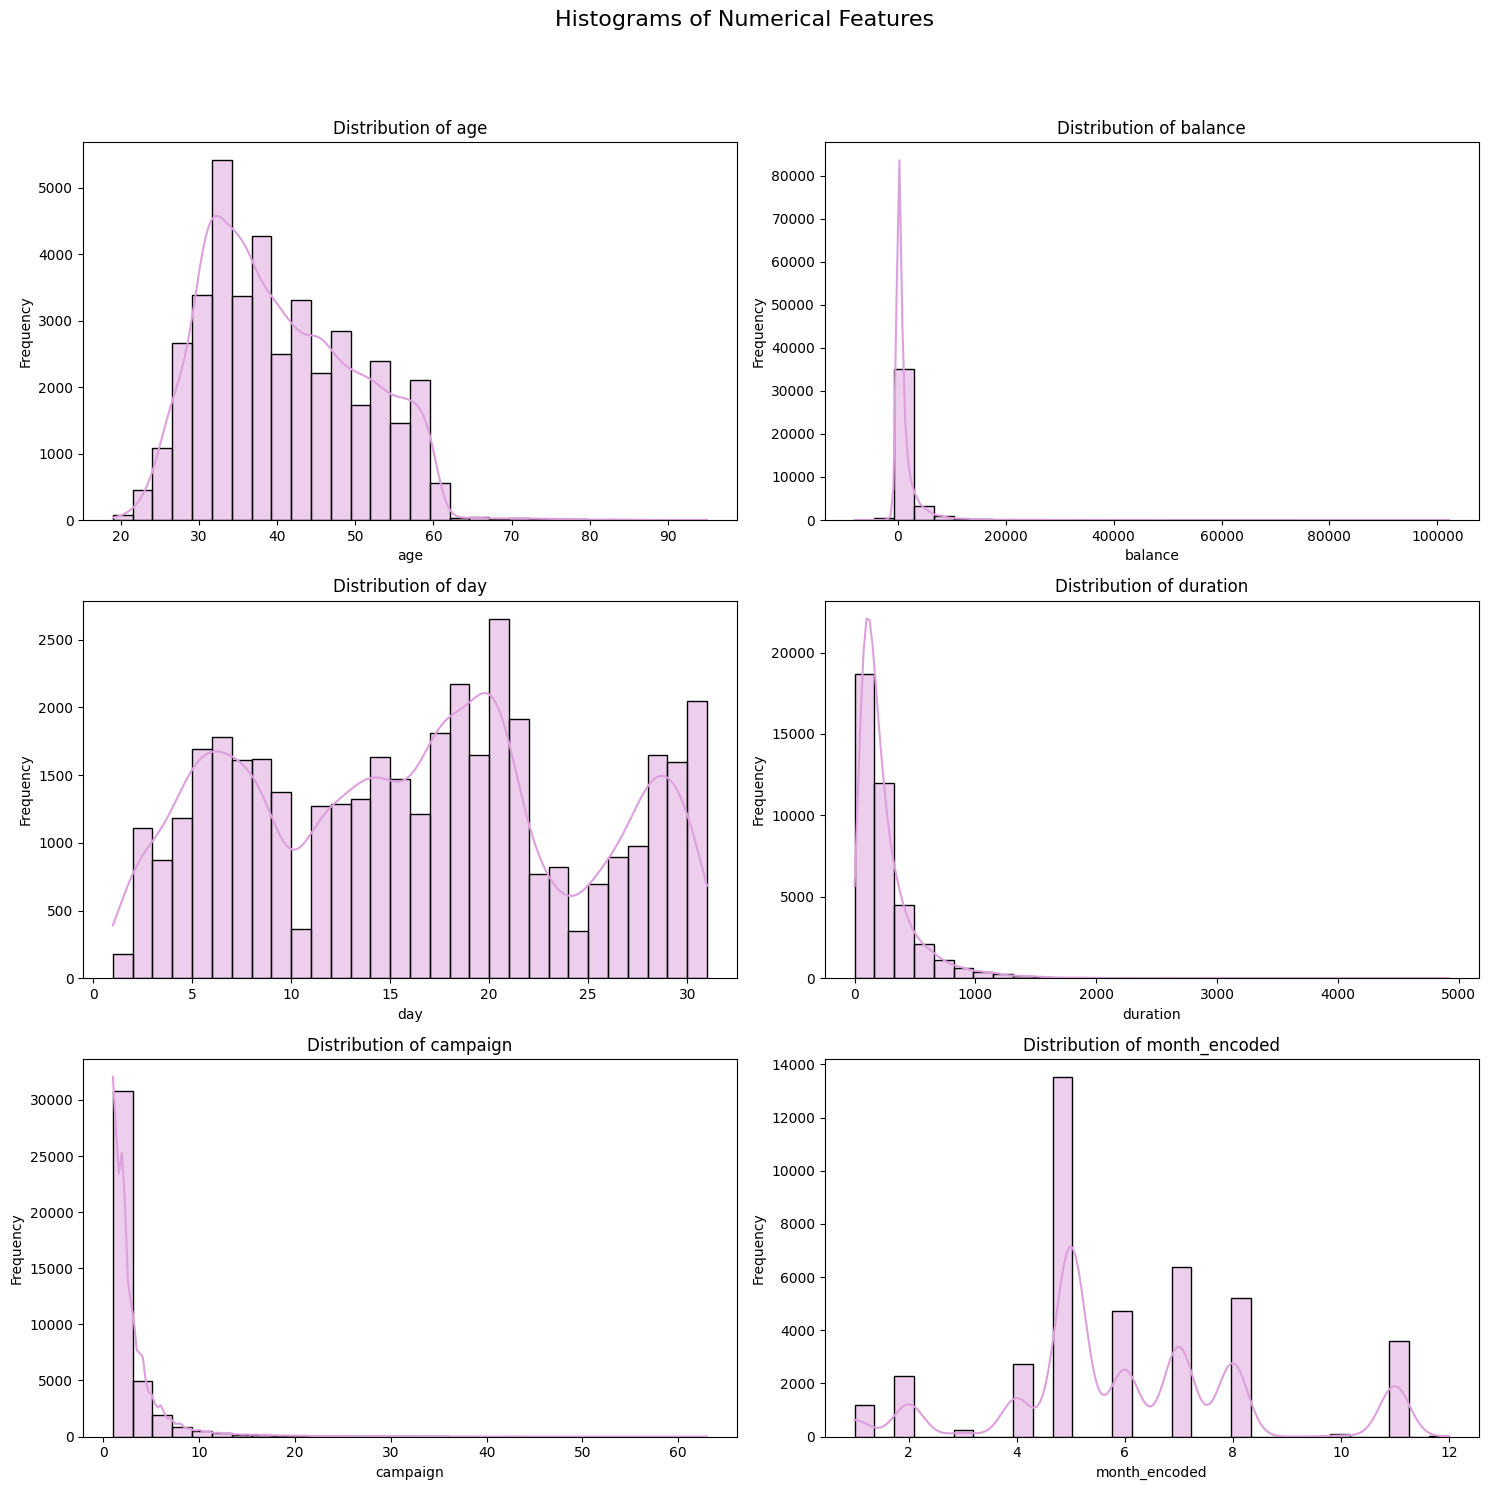

In [11]:
# plot histograms

fig, axes = plt.subplots(3, 2, figsize=(15, 15))
axes = axes.flatten()

cols = ['age', 'balance', 'day', 'duration', 'campaign', 'month_encoded']
for i, col in enumerate(cols):
    sns.histplot(data=df_encoded, x=col, kde=True, bins=30, edgecolor='black', color='plum', ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.suptitle('Histograms of Numerical Features', y=1.02, fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

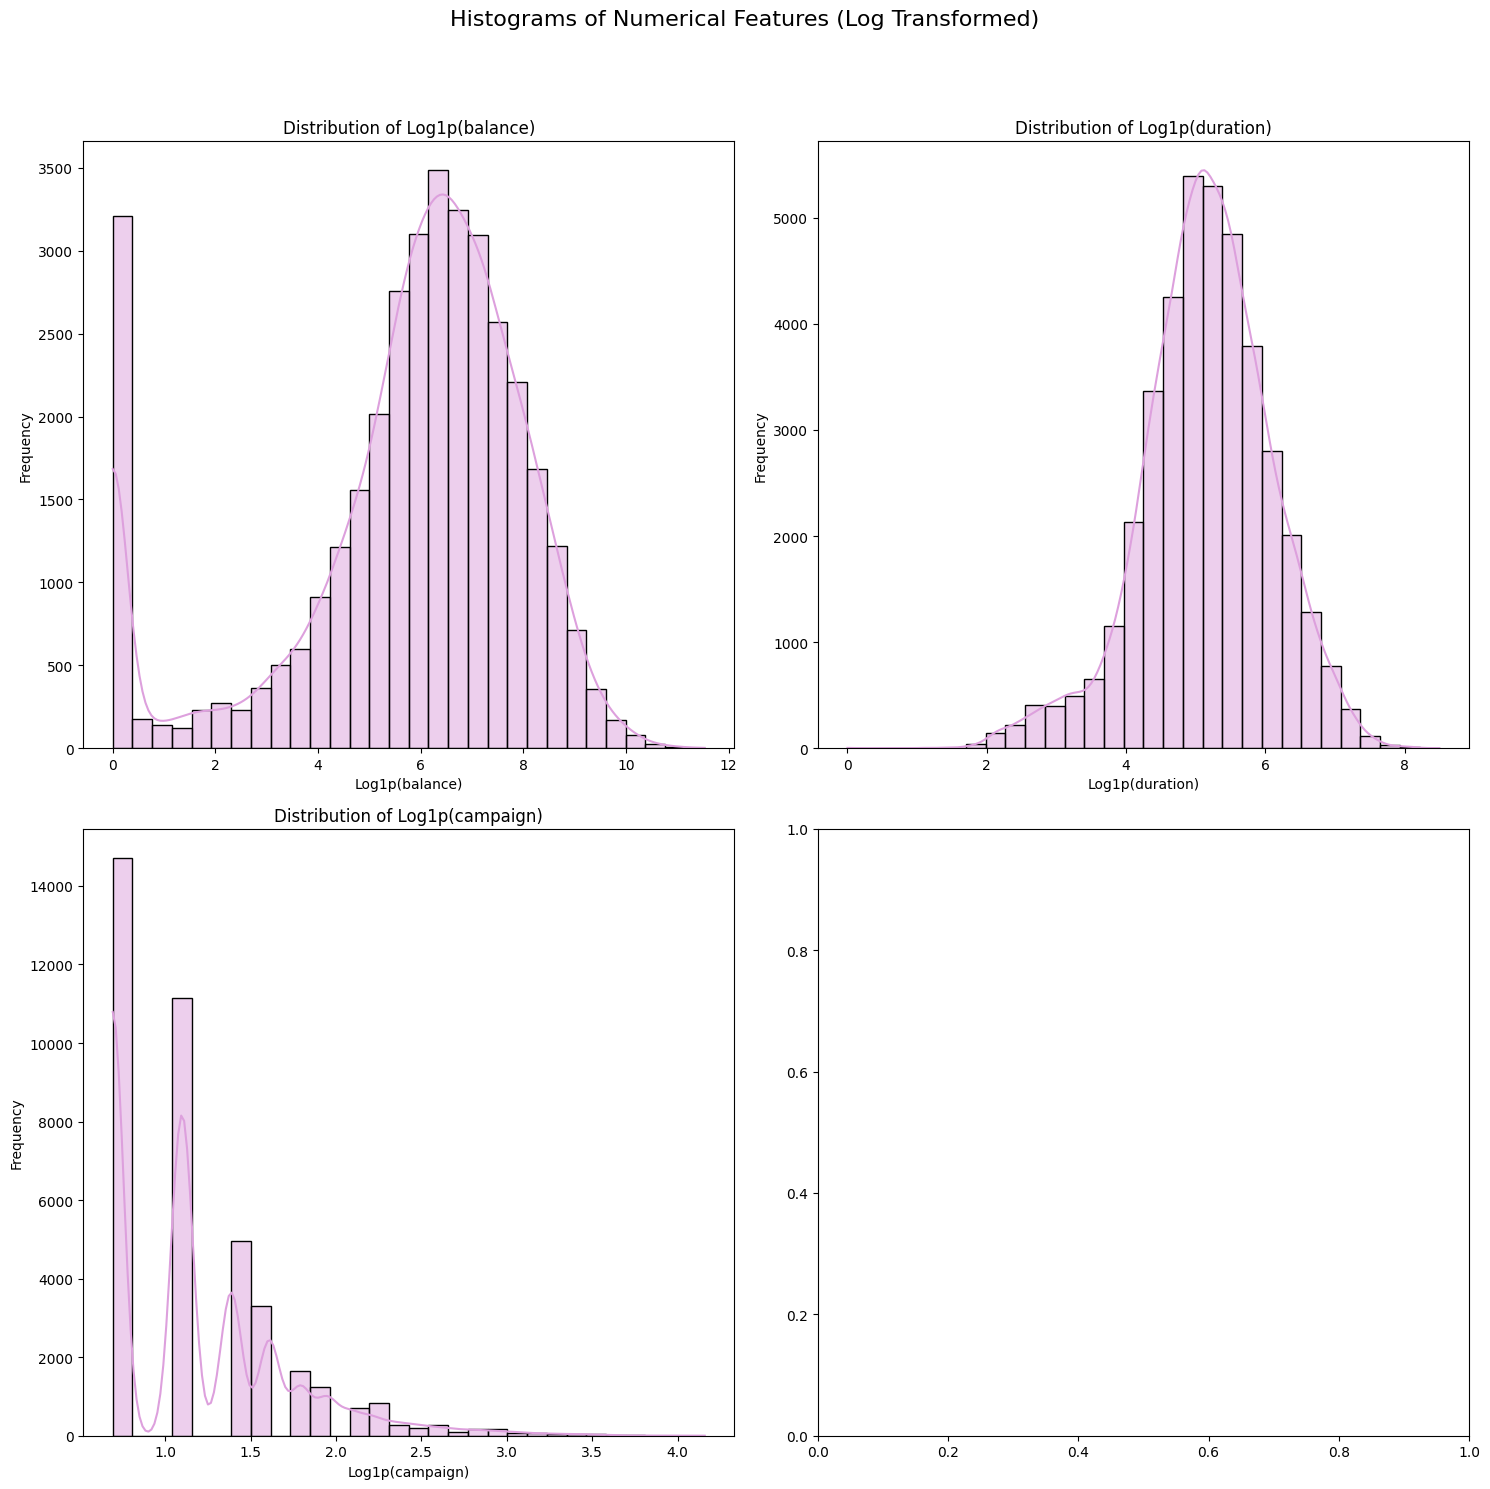

In [12]:
# plot histograms of campaign and balance as a log

fig, axes = plt.subplots(2, 2, figsize=(15, 15))
axes = axes.flatten()

cols_log = ['balance', 'duration', 'campaign']
for i, col in enumerate(cols_log):
    # Apply log1p transformation
    plot_data = np.log1p(df_encoded[col])

    sns.histplot(x=plot_data, kde=True, bins=30, edgecolor='black', color='plum', ax=axes[i])
    axes[i].set_title(f'Distribution of Log1p({col})')
    axes[i].set_xlabel(f'Log1p({col})')
    axes[i].set_ylabel('Frequency')

plt.suptitle('Histograms of Numerical Features (Log Transformed)', y=1.02, fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

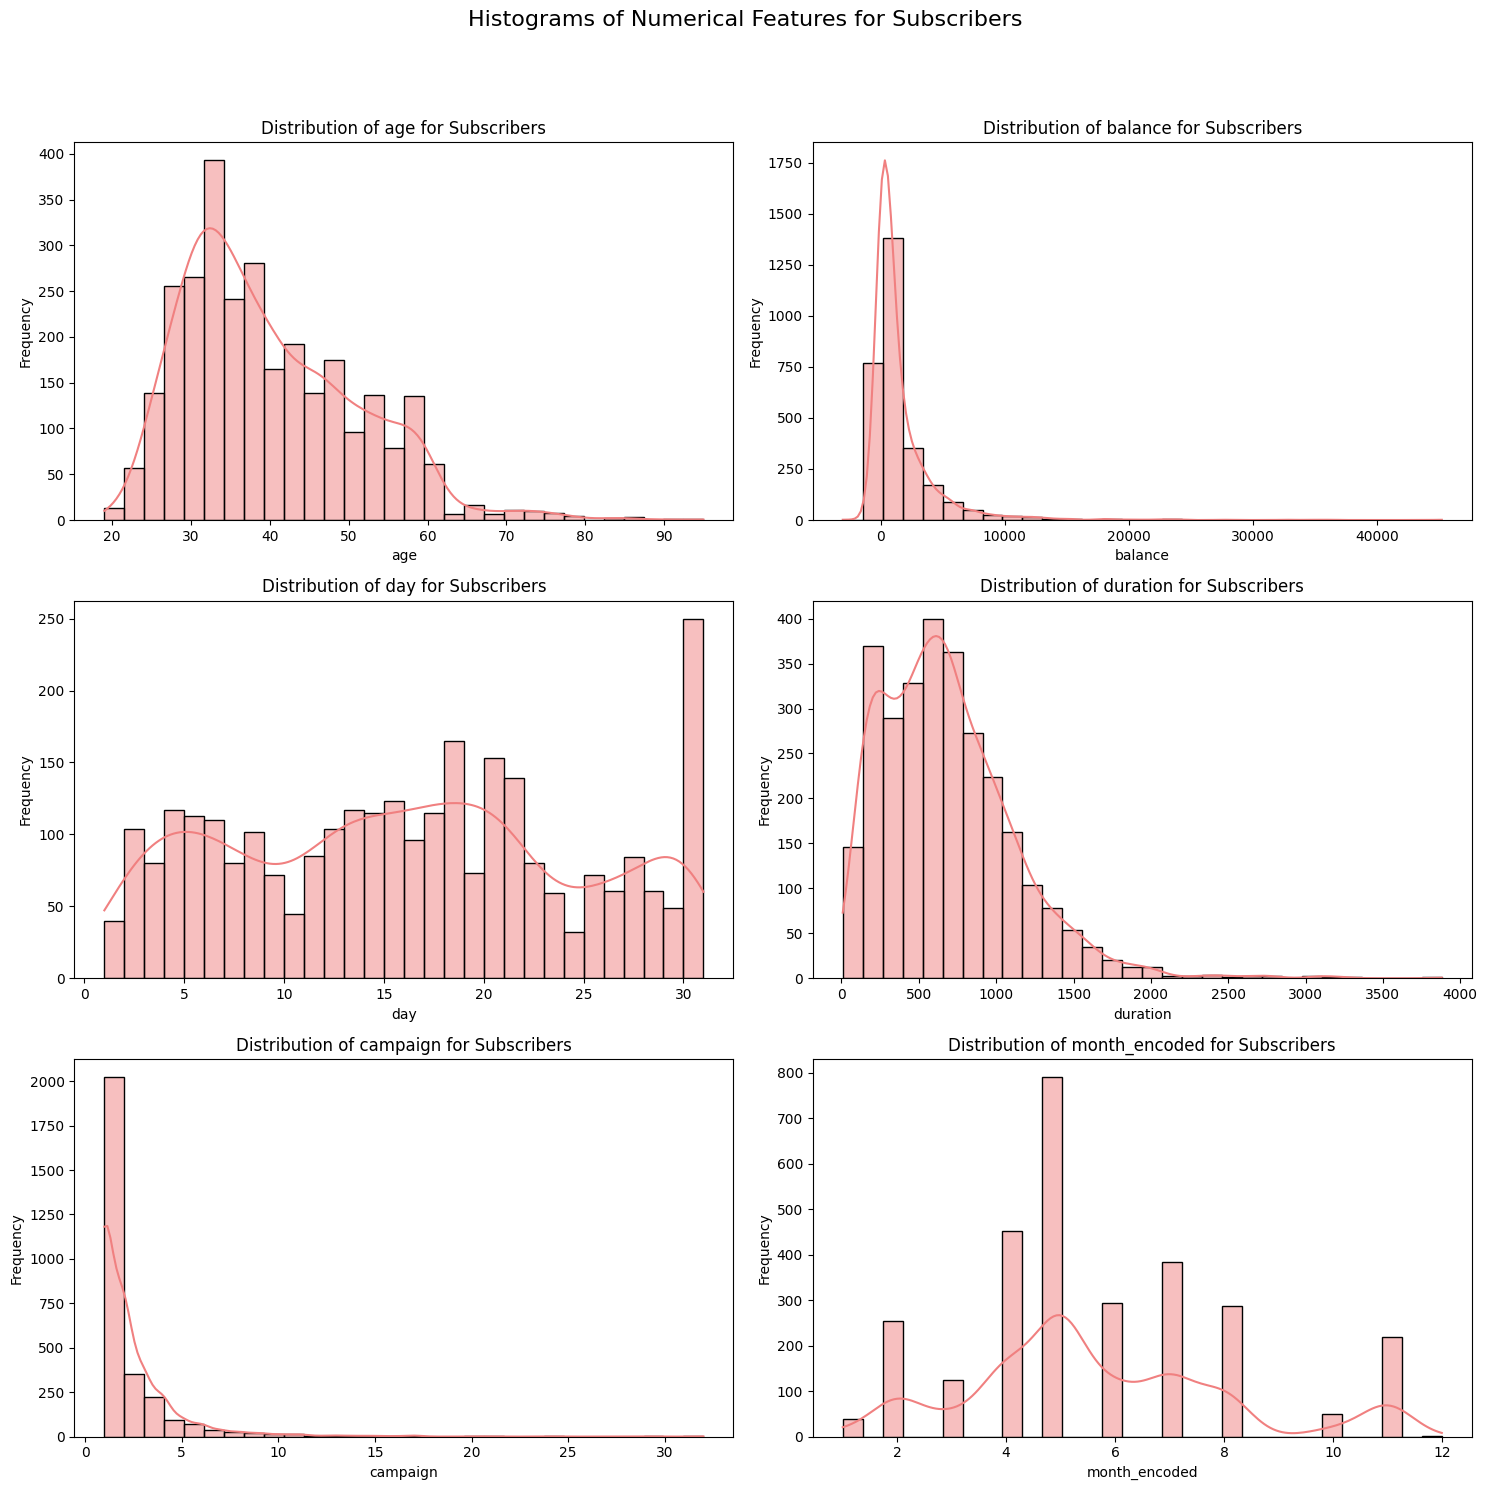

In [13]:
# plot histograms of subscribers

fig, axes = plt.subplots(3, 2, figsize=(15, 15))
axes = axes.flatten()

cols = ['age', 'balance', 'day', 'duration', 'campaign', 'month_encoded']
for i, col in enumerate(cols):
    sns.histplot(data=df_encoded_subs, x=col, kde=True, bins=30, edgecolor='black', color='lightcoral', ax=axes[i])
    axes[i].set_title(f'Distribution of {col} for Subscribers')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.suptitle('Histograms of Numerical Features for Subscribers', y=1.02, fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

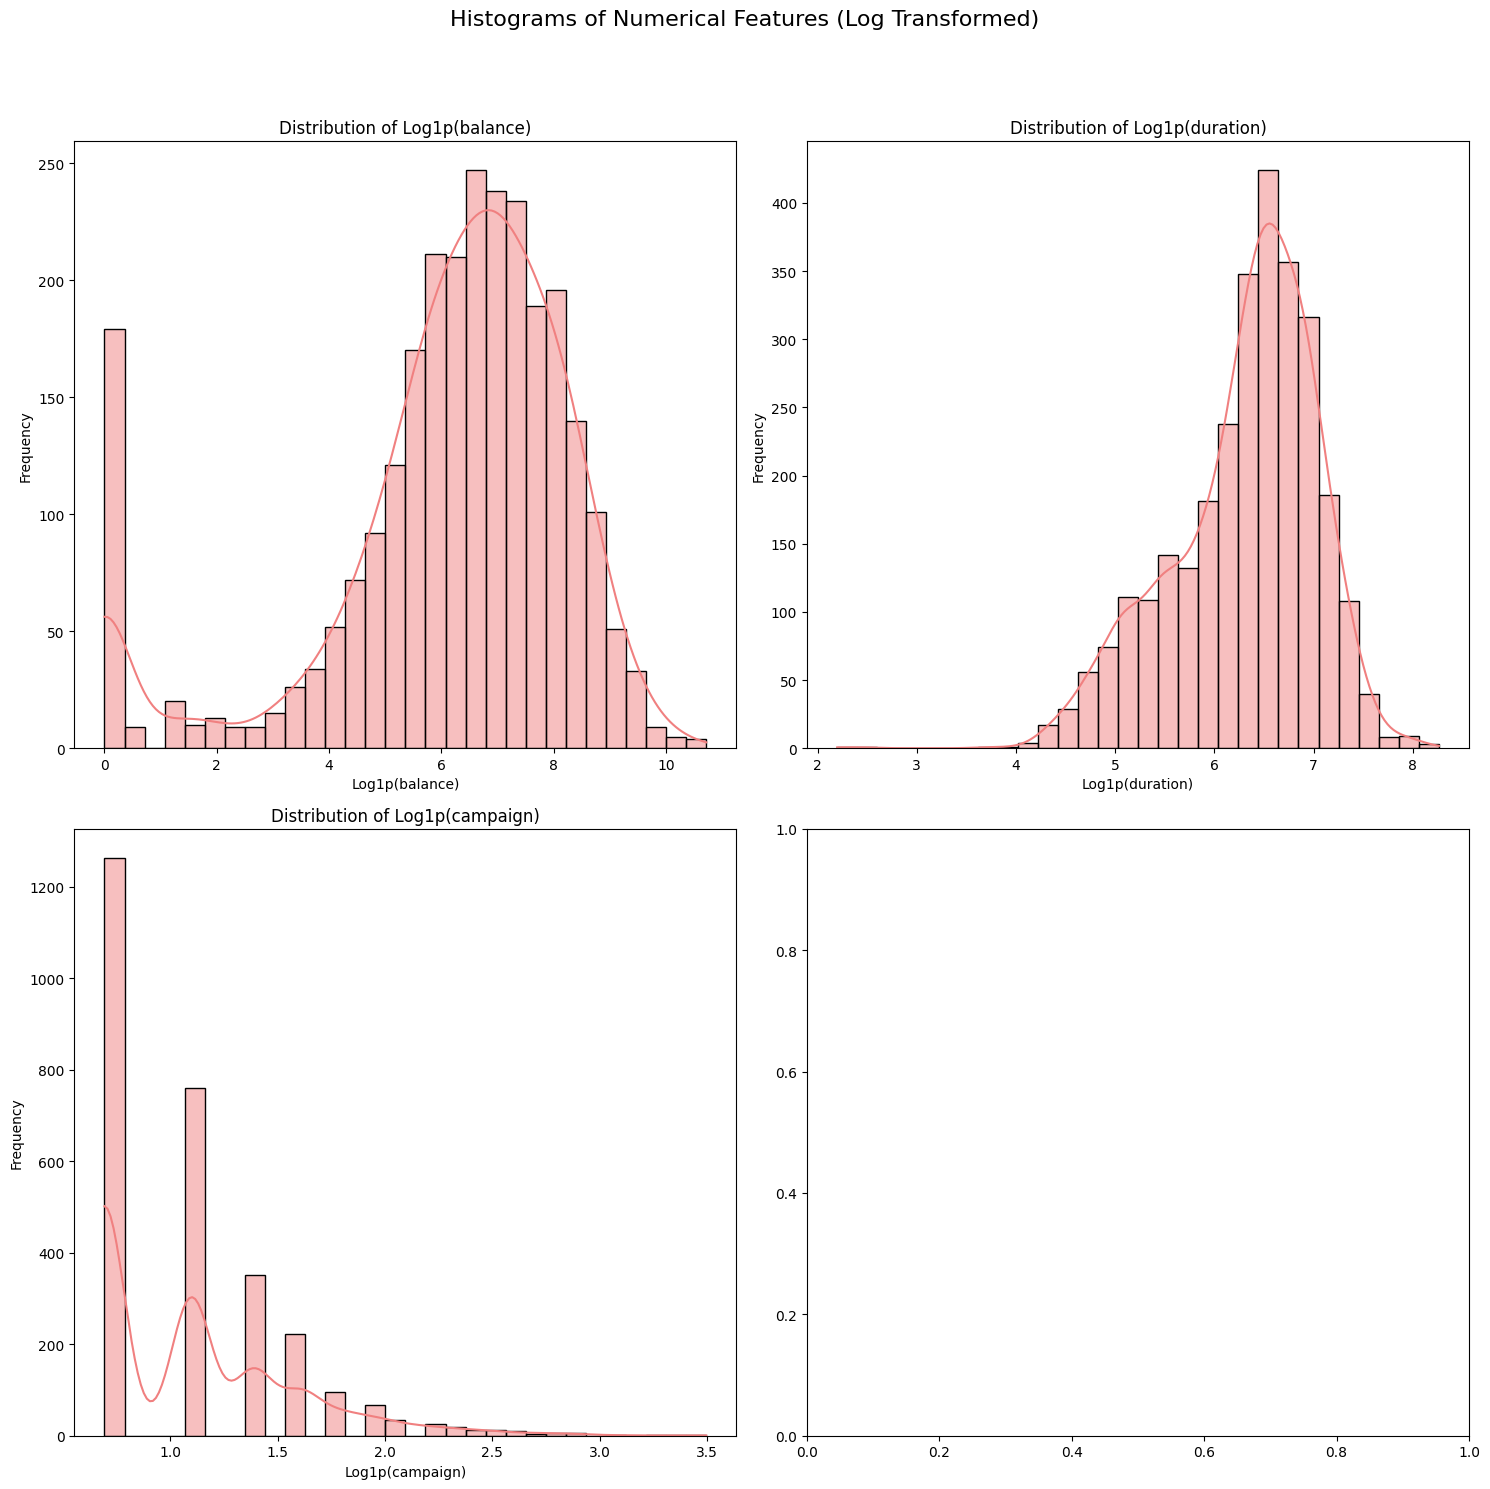

In [14]:
# plot histograms of campaign and balance as a log

fig, axes = plt.subplots(2, 2, figsize=(15, 15))
axes = axes.flatten()

cols_log = ['balance', 'duration', 'campaign']
for i, col in enumerate(cols_log):
    # Apply log1p transformation
    plot_data = np.log1p(df_encoded_subs[col])

    sns.histplot(x=plot_data, kde=True, bins=30, edgecolor='black', color='lightcoral', ax=axes[i])
    axes[i].set_title(f'Distribution of Log1p({col})')
    axes[i].set_xlabel(f'Log1p({col})')
    axes[i].set_ylabel('Frequency')

plt.suptitle('Histograms of Numerical Features (Log Transformed)', y=1.02, fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

This describes the company's successful attempts

#### Box plots

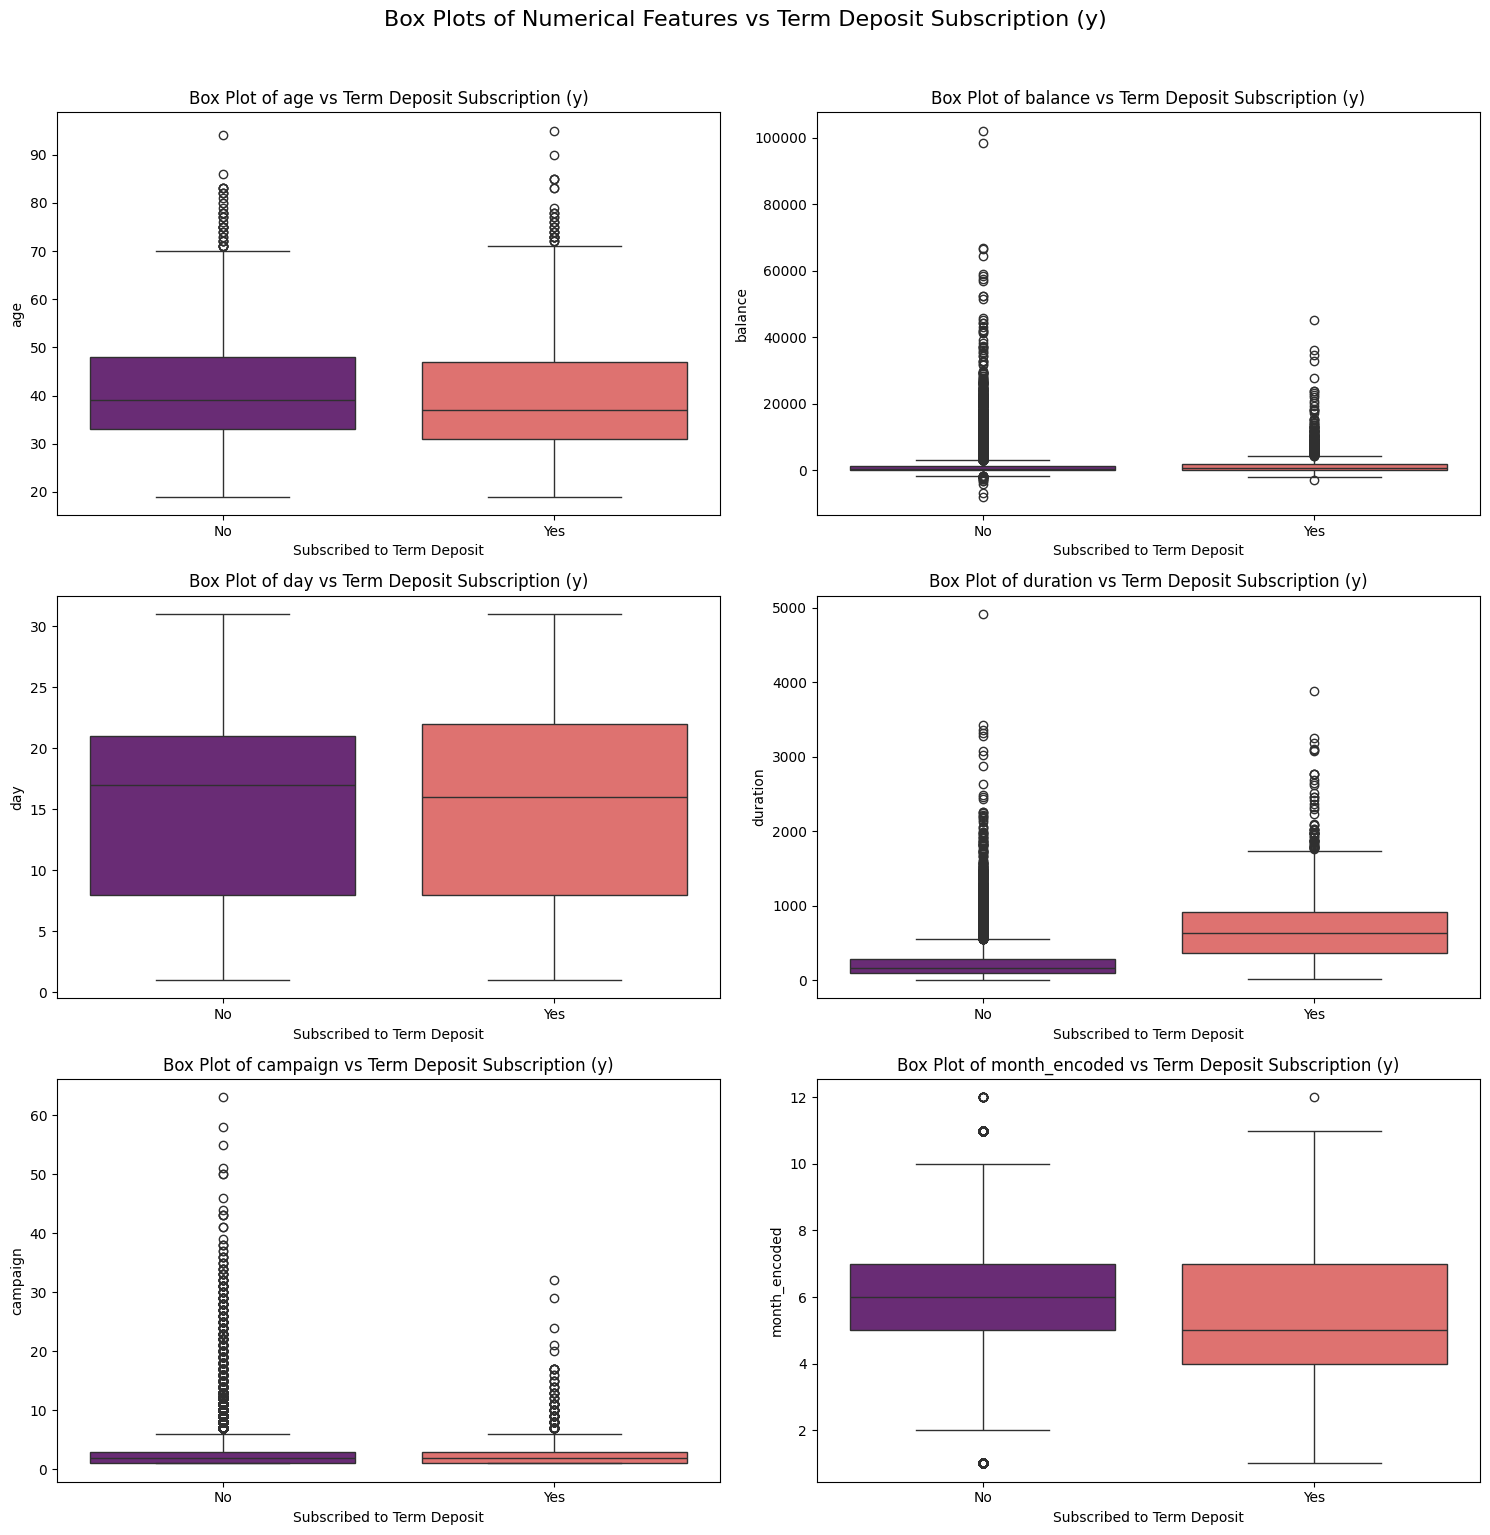

In [15]:
# Box Plots for Numerical Features vs Target Variable 'y'
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
axes = axes.flatten()

cols = ['age', 'balance', 'day', 'duration', 'campaign', 'month_encoded']
for i, col in enumerate(cols):
    sns.boxplot(x='y_encoded', y=col, data=df_encoded, palette='magma', ax=axes[i])
    axes[i].set_title(f'Box Plot of {col} vs Term Deposit Subscription (y)')
    axes[i].set_xlabel('Subscribed to Term Deposit')
    axes[i].set_ylabel(col)
    axes[i].set_xticklabels(['No', 'Yes'])

plt.suptitle('Box Plots of Numerical Features vs Term Deposit Subscription (y)', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

people say no when contacted too late. duration of the call is a sign they will say yes

#### Pearson Correlation

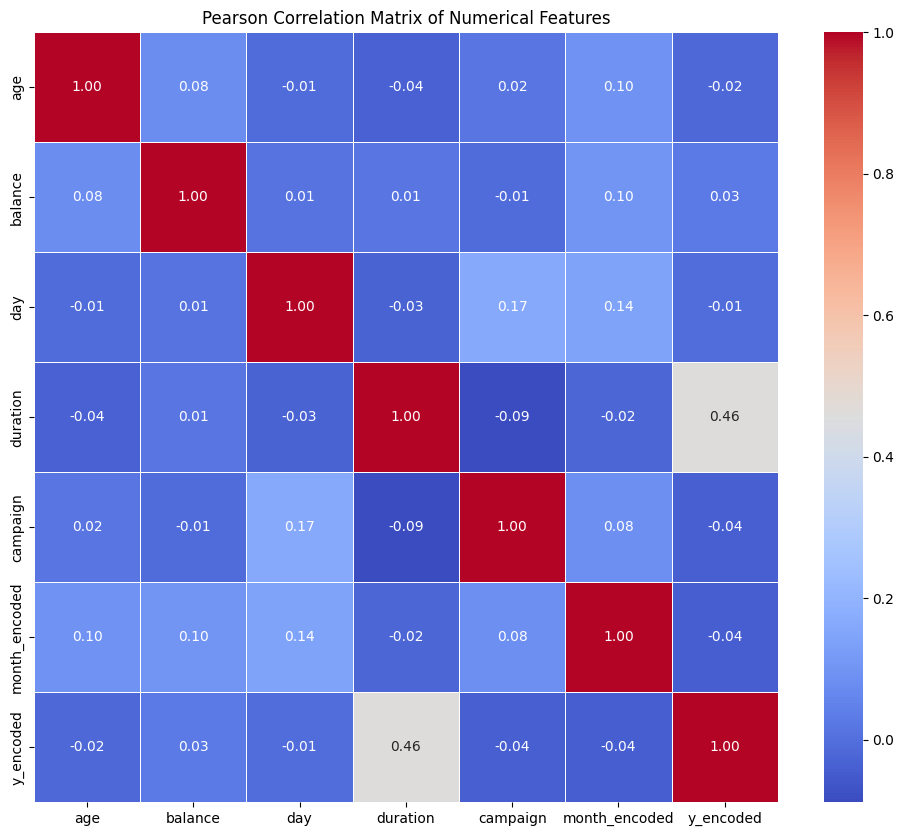

In [16]:
# Include only numerical columns for correlation matrix
correlation_matrix = df_encoded[numerical_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Pearson Correlation Matrix of Numerical Features')
plt.show()


#### Pair plot

In [17]:
# sns.pairplot(df_encoded[numerical_cols], hue='y_encoded', diag_kind='kde', palette='magma')
# plt.suptitle('Pair Plot of Selected Numerical Features with Target', y=1.02)
# plt.show()

In [18]:
# sns.pairplot(df_encoded_subs[cols], diag_kind='kde', palette='magma')
# plt.suptitle('Pair Plot of Selected Numerical Features for subscribers', y=1.02)
# plt.show()

#### duration vs. log(duration)

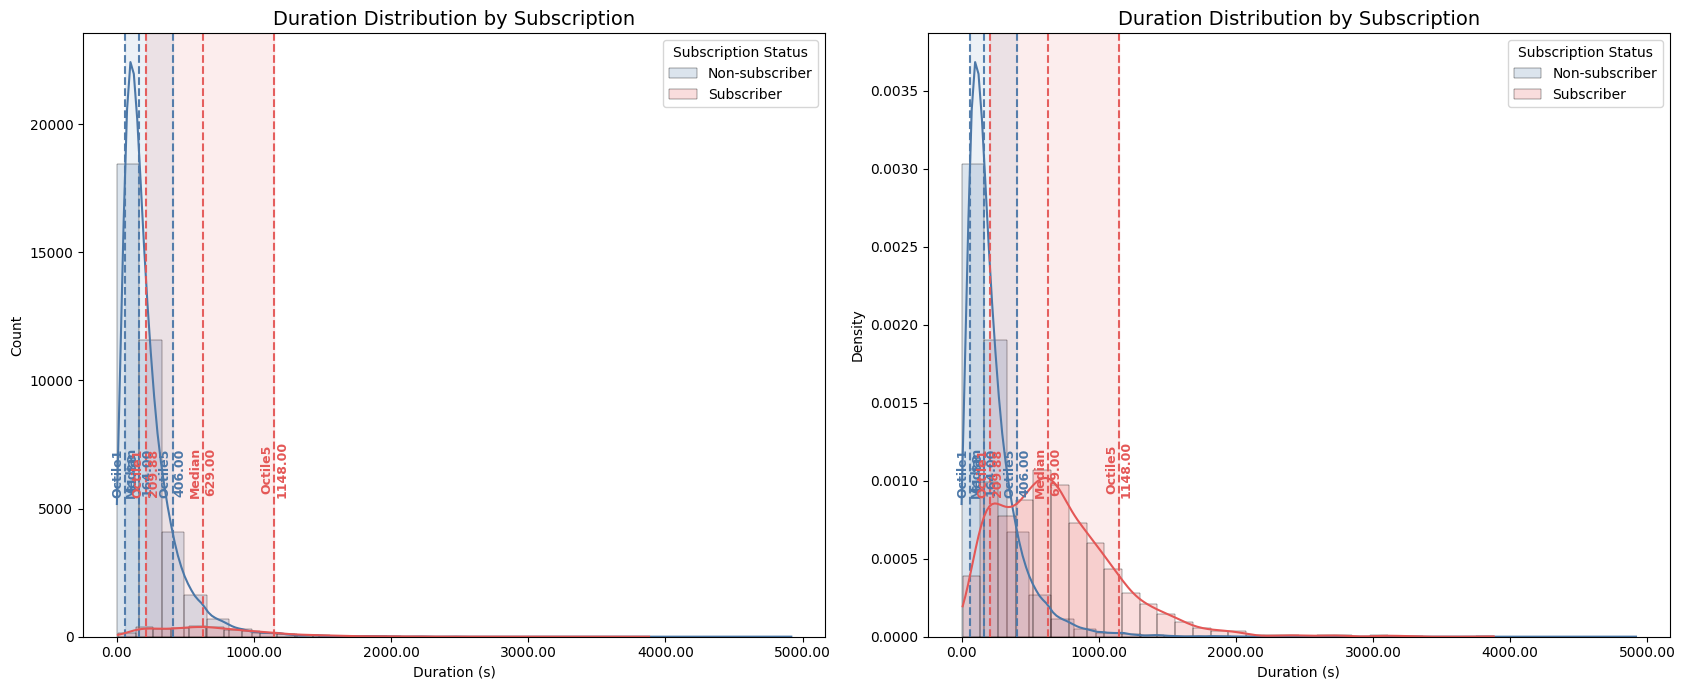

In [19]:
# Overlay duration distributions for subscribers vs non-subscribers
plot_df = df_encoded.copy()
plot_df['subscription'] = plot_df['y_encoded'].map({0: 'Non-subscriber', 1: 'Subscriber'})

group_colors = {
    'Non-subscriber': '#4C78A8',
    'Subscriber': '#E45756'
}

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(17,7))

for label, color in group_colors.items():
    group = plot_df[plot_df['subscription'] == label].copy()

    oct1, median, oct5 = group['duration'].quantile([0.125, 0.5, 0.875])

    # Shade the interquartile range
    ax[0].axvspan(oct1, oct5, color=color, alpha=0.10)

    # Overlay histogram + KDE
    sns.histplot(
        data=group,
        x='duration',
        bins=30,
        kde=True,
        stat='count',
        color=color,
        alpha=0.2,
        edgecolor='black',
        linewidth=0.25,
        ax=ax[0],
        label=label
    )

    # Vertical lines for Octile1, median, Octile5
    for q, name in [(oct1, 'Octile1'), (median, 'Median'), (oct5, 'Octile5')]:
        ax[0].axvline(q, color=color, linestyle='--', linewidth=1.5, alpha=0.95)
        ax[0].annotate(
            f'{name}\n{q:.2f}',
            xy=(q, 0),
            xycoords=('data', 'axes fraction'),
            xytext=(0, 100),
            textcoords='offset points',
            ha='center',
            va='bottom',
            fontsize=9,
            color=color,
            weight='bold',
            clip_on=False,
            rotation=90
        )

ax[0].set_title('Duration Distribution by Subscription', fontsize=14)
ax[0].set_xlabel('Duration (s)')
ax[0].set_ylabel('Count')

# Make the x tick labels color coded to match each group
xticks = ax[0].get_xticks()
ax[0].set_xticklabels([f'{x:.2f}' for x in xticks], color='black')

# add legend
ax[0].legend(title='Subscription Status', loc='upper right')



for label, color in group_colors.items():
    group = plot_df[plot_df['subscription'] == label].copy()

    oct1, median, oct5 = group['duration'].quantile([0.125, 0.5, 0.875])

    # Shade the interquartile range
    ax[1].axvspan(oct1, oct5, color=color, alpha=0.10)

    # Overlay histogram + KDE
    sns.histplot(
        data=group,
        x='duration',
        bins=30,
        kde=True,
        stat='density',
        color=color,
        alpha=0.2,
        edgecolor='black',
        linewidth=0.25,
        ax=ax[1],
        label=label
    )

    # Vertical lines for oct1, median, oct5
    for q, name in [(oct1, 'Octile1'), (median, 'Median'), (oct5, 'Octile5')]:
        ax[1].axvline(q, color=color, linestyle='--', linewidth=1.5, alpha=0.95)
        ax[1].annotate(
            f'{name}\n{q:.2f}',
            xy=(q, 0),
            xycoords=('data', 'axes fraction'),
            xytext=(0, 100),
            textcoords='offset points',
            ha='center',
            va='bottom',
            fontsize=9,
            color=color,
            weight='bold',
            clip_on=False,
            rotation=90
        )

ax[1].set_title('Duration Distribution by Subscription', fontsize=14)
ax[1].set_xlabel('Duration (s)')
ax[1].set_ylabel('Density')

# Make the x tick labels color coded to match each group
xticks = ax[1].get_xticks()
ax[1].set_xticklabels([f'{x:.2f}' for x in xticks], color='black')

# add legend
ax[1].legend(title='Subscription Status', loc='upper right')


plt.tight_layout()
plt.show()

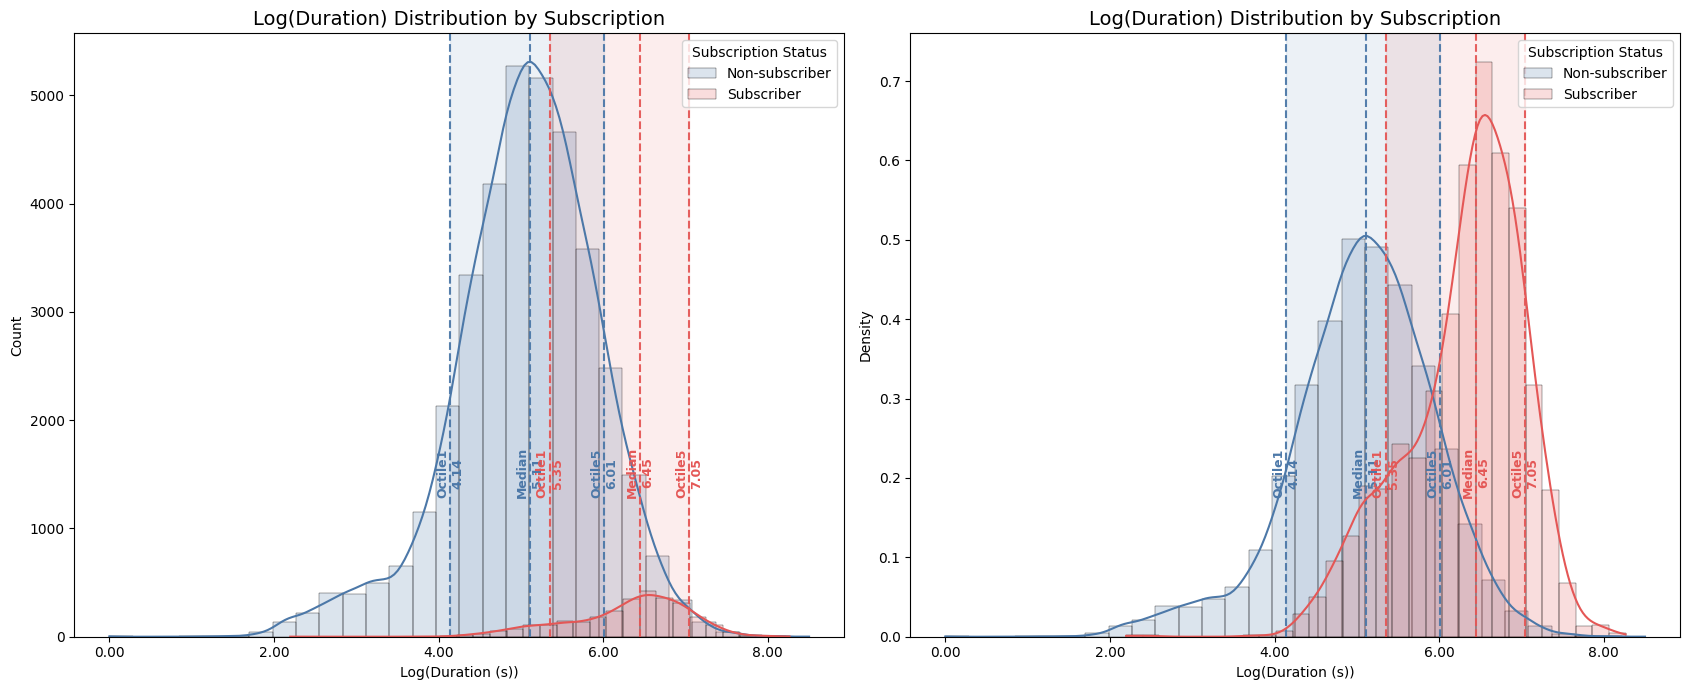

In [20]:
# Overlay duration distributions for subscribers vs non-subscribers
plot_df = df_encoded.copy()
plot_df['log_duration'] = plot_df['duration'].apply(lambda x: np.log1p(x))
plot_df['subscription'] = plot_df['y_encoded'].map({0: 'Non-subscriber', 1: 'Subscriber'})

group_colors = {
    'Non-subscriber': '#4C78A8',
    'Subscriber': '#E45756'
}

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(17,7))

for label, color in group_colors.items():
    group = plot_df[plot_df['subscription'] == label].copy()

    oct1, median, oct5 = group['log_duration'].quantile([0.125, 0.5, 0.875])

    # Shade the interquartile range
    ax[0].axvspan(oct1, oct5, color=color, alpha=0.10)

    # Overlay histogram + KDE
    sns.histplot(
        data=group,
        x='log_duration',
        bins=30,
        kde=True,
        stat='count',
        color=color,
        alpha=0.2,
        edgecolor='black',
        linewidth=0.25,
        ax=ax[0],
        label=label
    )

    # Vertical lines for oct1, median, oct5
    for q, name in [(oct1, 'Octile1'), (median, 'Median'), (oct5, 'Octile5')]:
        ax[0].axvline(q, color=color, linestyle='--', linewidth=1.5, alpha=0.95)
        ax[0].annotate(
            f'{name}\n{q:.2f}',
            xy=(q, 0),
            xycoords=('data', 'axes fraction'),
            xytext=(0, 100),
            textcoords='offset points',
            ha='center',
            va='bottom',
            fontsize=9,
            color=color,
            weight='bold',
            clip_on=False,
            rotation=90
        )

ax[0].set_title('Log(Duration) Distribution by Subscription', fontsize=14)
ax[0].set_xlabel('Log(Duration (s))')
ax[0].set_ylabel('Count')

# Make the x tick labels color coded to match each group
xticks = ax[0].get_xticks()
ax[0].set_xticklabels([f'{x:.2f}' for x in xticks], color='black')

# add legend
ax[0].legend(title='Subscription Status', loc='upper right')



for label, color in group_colors.items():
    group = plot_df[plot_df['subscription'] == label].copy()

    oct1, median, oct5 = group['log_duration'].quantile([0.125, 0.5, 0.875])

    # Shade the interquartile range
    ax[1].axvspan(oct1, oct5, color=color, alpha=0.10)

    # Overlay histogram + KDE
    sns.histplot(
        data=group,
        x='log_duration',
        bins=30,
        kde=True,
        stat='density',
        color=color,
        alpha=0.2,
        edgecolor='black',
        linewidth=0.25,
        ax=ax[1],
        label=label
    )

    # Vertical lines for oct1, median, oct5
    for q, name in [(oct1, 'Octile1'), (median, 'Median'), (oct5, 'Octile5')]:
        ax[1].axvline(q, color=color, linestyle='--', linewidth=1.5, alpha=0.95)
        ax[1].annotate(
            f'{name}\n{q:.2f}',
            xy=(q, 0),
            xycoords=('data', 'axes fraction'),
            xytext=(0, 100),
            textcoords='offset points',
            ha='center',
            va='bottom',
            fontsize=9,
            color=color,
            weight='bold',
            clip_on=False,
            rotation=90
        )

ax[1].set_title('Log(Duration) Distribution by Subscription', fontsize=14)
ax[1].set_xlabel('Log(Duration (s))')
ax[1].set_ylabel('Density')

# Make the x tick labels color coded to match each group
xticks = ax[1].get_xticks()
ax[1].set_xticklabels([f'{x:.2f}' for x in xticks], color='black')

# add legend
ax[1].legend(title='Subscription Status', loc='upper right')


plt.tight_layout()
plt.show()

#### EDA Conclusion
Based on this EDA, we can observe the following:

- The target variable 'y' is highly imbalanced, with a much smaller proportion of 'yes' subscriptions. This will be a key challenge for model training.
- The 'duration' feature seems to have a strong positive correlation with 'y_encoded', suggesting that longer contact durations are associated with higher subscription rates. Perhaps it would be possible to use that as a success metric.
- Other features like 'age' and 'balance' show weaker correlations but their distributions vary between 'yes' and 'no' subscribers.
- Categorical features reveal varying subscription rates across different job types, marital statuses, and education levels, which can be explored further for customer segmentation.
- Features like 'campaign' (number of contacts) show an inverse relationship with subscription rate after a certain point, suggesting that too many contacts might be detrimental.

#### onehot encoding

In [21]:
df_encoded_onehot = pd.get_dummies(df_encoded, columns=['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month_encoded'], drop_first=False)
df_encoded_onehot = df_encoded_onehot.drop(['month'], axis=1)
df_encoded_onehot.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 45 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   age                  40000 non-null  int64
 1   balance              40000 non-null  int64
 2   day                  40000 non-null  int64
 3   duration             40000 non-null  int64
 4   campaign             40000 non-null  int64
 5   y_encoded            40000 non-null  int64
 6   job_admin            40000 non-null  bool 
 7   job_blue-collar      40000 non-null  bool 
 8   job_entrepreneur     40000 non-null  bool 
 9   job_housemaid        40000 non-null  bool 
 10  job_management       40000 non-null  bool 
 11  job_retired          40000 non-null  bool 
 12  job_self-employed    40000 non-null  bool 
 13  job_services         40000 non-null  bool 
 14  job_student          40000 non-null  bool 
 15  job_technician       40000 non-null  bool 
 16  job_unemployed       4

In [22]:
# Add a log-transformed duration
df_encoded_onehot['log_duration'] = np.log1p(df_encoded_onehot['duration'])

print(df_encoded_onehot[['duration', 'log_duration']].head())

   duration  log_duration
0       261      5.568345
1       151      5.023881
2        76      4.343805
3        92      4.532599
4       198      5.293305


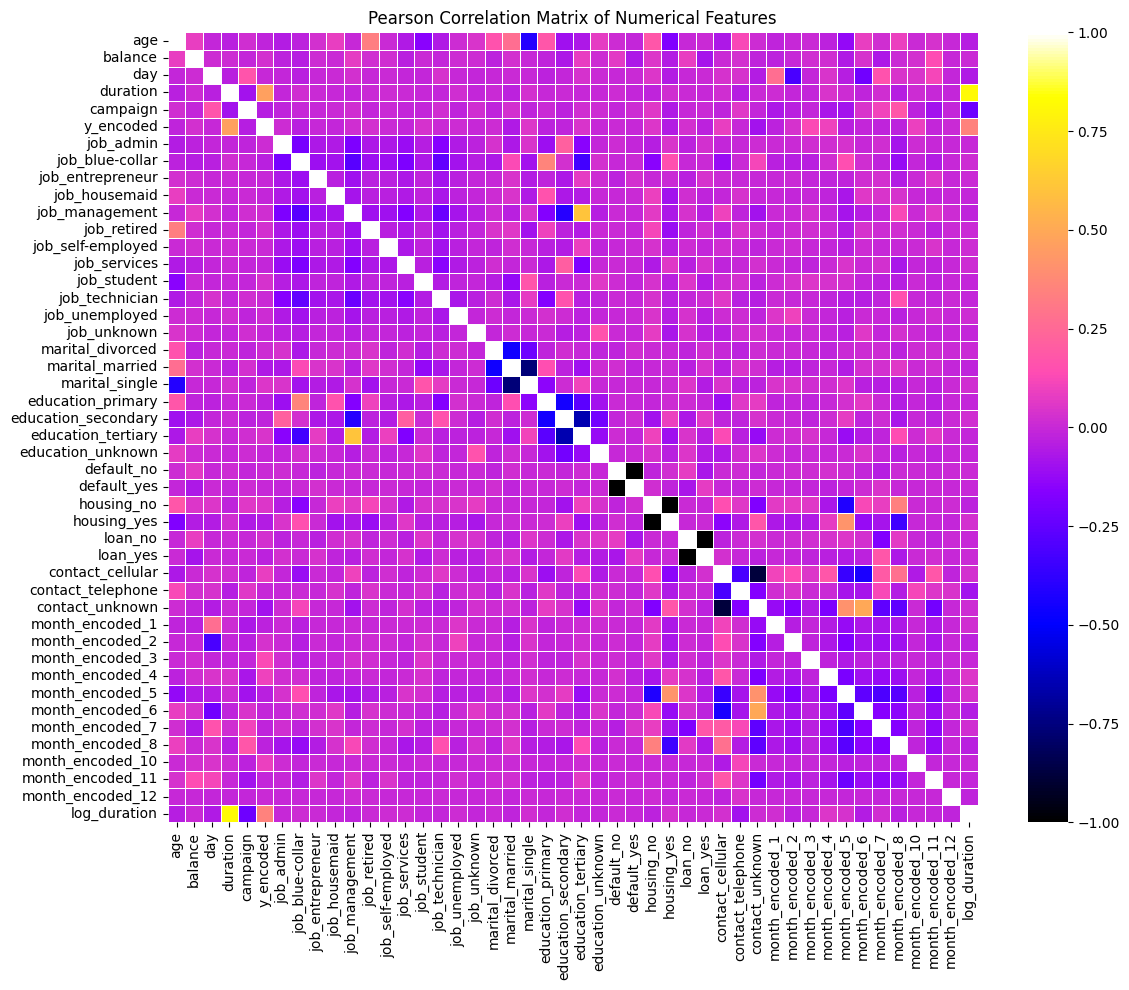

In [23]:
# run pearson correlation on the one hot encoded data
correlation_matrix = df_encoded_onehot.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, cmap='gnuplot2', linewidths=.5)
plt.title('Pearson Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

In [24]:
# print correlation with y_encoded
print('Correlation with y_encoded')
print(correlation_matrix['y_encoded'].sort_values(ascending=False))

Correlation with y_encoded
y_encoded              1.000000
duration               0.461169
log_duration           0.348575
month_encoded_3        0.128125
month_encoded_4        0.097450
month_encoded_10       0.093298
contact_cellular       0.085433
housing_no             0.054336
marital_single         0.051721
education_tertiary     0.046763
job_student            0.037384
month_encoded_2        0.036816
loan_no                0.031029
balance                0.030232
job_retired            0.024343
job_management         0.020291
marital_divorced       0.014619
job_unemployed         0.009463
job_admin              0.008083
default_no             0.006559
job_self-employed      0.005029
month_encoded_12       0.000315
job_technician         0.000234
job_unknown           -0.000018
contact_telephone     -0.000842
day                   -0.006420
default_yes           -0.006559
job_entrepreneur      -0.007191
education_unknown     -0.007464
month_encoded_11      -0.013654
month_encoded

In [25]:
# print correlation with log_duration
print('Correlation with log_duration')
print(correlation_matrix['log_duration'].sort_values(ascending=False))

Correlation with log_duration
log_duration           1.000000
duration               0.815576
y_encoded              0.348575
month_encoded_4        0.054360
month_encoded_5        0.032809
contact_cellular       0.030211
housing_yes            0.027050
education_secondary    0.023025
month_encoded_1        0.020462
marital_single         0.018635
month_encoded_7        0.017358
job_blue-collar        0.015384
job_unemployed         0.013887
contact_unknown        0.011702
job_services           0.010006
job_self-employed      0.007825
job_retired            0.006245
balance                0.005758
marital_divorced       0.005329
default_no             0.005033
loan_yes               0.004946
job_entrepreneur       0.002514
job_admin             -0.000739
month_encoded_10      -0.004755
loan_no               -0.004946
default_yes           -0.005033
month_encoded_3       -0.005075
job_technician        -0.008484
education_unknown     -0.010288
education_tertiary    -0.010965
job_studen

# Modelling

In [26]:
!pip install xgboost

In [27]:
# set SEED
seed = 888

In [28]:
from lazypredict.Supervised import LazyClassifier, LazyRegressor
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [29]:
# Prepare the data for modelling
# Convert boolean columns to int (0/1) for model compatibility
bool_cols = df_encoded_onehot.select_dtypes(include='bool').columns
df_encoded_onehot[bool_cols] = df_encoded_onehot[bool_cols].astype(int)

# Define Stage 0 features
X_stage0 = df_encoded_onehot.drop(['duration', 'log_duration', 'y_encoded', 'day', 'campaign', 'contact_cellular', 'contact_telephone',
                                   'contact_unknown', 'month_encoded_1', 'month_encoded_2', 'month_encoded_3', 'month_encoded_4',
                                   'month_encoded_5', 'month_encoded_6', 'month_encoded_7', 'month_encoded_8',
                                   'month_encoded_10', 'month_encoded_11', 'month_encoded_12'], axis=1)

# Define Targets
y_classification = df_encoded_onehot['y_encoded']
y_regression = df_encoded_onehot['duration']
y_regression_log = df_encoded_onehot['log_duration']

print(f"Features shape: {X_stage0.shape}")
print(f"Classification target distribution:\n{y_classification.value_counts(normalize=True)}\n{y_classification.value_counts(normalize=False)}")

Features shape: (40000, 27)
Classification target distribution:
y_encoded
0    0.9276
1    0.0724
Name: proportion, dtype: float64
y_encoded
0    37104
1     2896
Name: count, dtype: int64


In [30]:
# Print number of datapoints in the IQR of subscribers and non subscribers

# Define the quartile ranges for subscribers and non-subscribers (Duraton)
sub_oct1, sub_median, sub_oct5 = df_encoded_onehot[df_encoded_onehot['y_encoded'] == 1]['duration'].quantile([0.125, 0.5, 0.875])

non_sub_oct1, non_sub_median, non_sub_oct5 = df_encoded_onehot[df_encoded_onehot['y_encoded'] == 0]['duration'].quantile([0.125, 0.5, 0.875])

# Define the quartile ranges for subscribers and non-subscribers (Log Duration)
log_sub_oct1, log_sub_median, log_sub_oct5 = df_encoded_onehot[df_encoded_onehot['y_encoded'] == 1]['log_duration'].quantile([0.125, 0.5, 0.875])

log_non_sub_oct1, log_non_sub_median, log_non_sub_oct5 = df_encoded_onehot[df_encoded_onehot['y_encoded'] == 0]['log_duration'].quantile([0.125, 0.5, 0.875])


# calculate count of datapoints
sub_count = df_encoded_onehot[(df_encoded_onehot['duration'] >= sub_oct1) & (df_encoded_onehot['duration'] <= sub_oct5)].shape[0]
non_sub_count = df_encoded_onehot[(df_encoded_onehot['duration'] >= non_sub_oct1) & (df_encoded_onehot['duration'] <= non_sub_oct5)].shape[0]

log_sub_count = df_encoded_onehot[(df_encoded_onehot['log_duration'] >= log_sub_oct1) & (df_encoded_onehot['log_duration'] <= log_sub_oct5)].shape[0]
log_non_sub_count = df_encoded_onehot[(df_encoded_onehot['log_duration'] >= log_non_sub_oct1) & (df_encoded_onehot['log_duration'] <= log_non_sub_oct5)].shape[0]

# print resutls
print ('-------Duration data-------')
print(f'Subscribers:\tOctile1: {sub_oct1}\n\t\tMedian: {sub_median}\n\t\tOctile5: {sub_oct5}')
print(f"Number of datapoints in the IQR of subscribers: {sub_count} ({100*sub_count/df_encoded_onehot.shape[0]:.2f}%) out of {df_encoded_onehot.shape[0]}")
print(f'\nNon-Subscribers:Octile1: {non_sub_oct1}\n\t\tMedian: {non_sub_median}\n\t\tOctile5: {non_sub_oct5}')
print(f"Number of datapoints in the IQR of non-subscribers: {non_sub_count} ({100*non_sub_count/df_encoded_onehot.shape[0]:.2f}%) out of {df_encoded_onehot.shape[0]}")

print('\n\n-------Log(Duration) data-------')
print(f'Subscribers:\tOctile1: {log_sub_oct1:.4f}\n\t\tMedian: {log_sub_median:.4f}\n\t\tOctile5: {log_sub_oct5:.4f}')
print(f"Number of datapoints in the IQR of subscribers: {log_sub_count} ({100*log_sub_count/df_encoded_onehot.shape[0]:.2f}%) out of {df_encoded_onehot.shape[0]}")
print(f'\nNon-Subscribers:Octile1: {log_non_sub_oct1:.4f}\n\t\tMedian: {log_non_sub_median:.4f}\n\t\tOctile5: {log_non_sub_oct5:.4f}')
print(f"Number of datapoints in the IQR of non-subscribers: {log_non_sub_count} ({100*log_non_sub_count/df_encoded_onehot.shape[0]:.2f}%) out of {df_encoded_onehot.shape[0]}")

-------Duration data-------
Subscribers:	Octile1: 209.875
		Median: 629.0
		Octile5: 1148.0
Number of datapoints in the IQR of subscribers: 16037 (40.09%) out of 40000

Non-Subscribers:Octile1: 61.875
		Median: 164.0
		Octile5: 406.0
Number of datapoints in the IQR of non-subscribers: 28682 (71.70%) out of 40000


-------Log(Duration) data-------
Subscribers:	Octile1: 5.3513
		Median: 6.4457
		Octile5: 7.0466
Number of datapoints in the IQR of subscribers: 16037 (40.09%) out of 40000

Non-Subscribers:Octile1: 4.1411
		Median: 5.1059
		Octile5: 6.0088
Number of datapoints in the IQR of non-subscribers: 28682 (71.70%) out of 40000


In [31]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Split data into training and testing sets
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_stage0, y_regression, test_size=0.3, random_state=seed)

# Printt test/train split numbers
print(f"X_train_reg shape: {X_train_reg.shape}")
print(f"X_test_reg shape: {X_test_reg.shape}")

regressors = {
    'Decision Tree': DecisionTreeRegressor(
        max_depth=5,
        random_state=seed
    ),
    'Random Forest': RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        random_state=seed,
        n_jobs=-1
    ),
    'XGBoost': XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=seed,
        objective='reg:squarederror',
        n_jobs=-1
    ),
    'HistGradientBoosting': HistGradientBoostingRegressor(
        max_iter=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=seed
    )
}

results = []

for name, model in regressors.items():
    model.fit(X_train_reg, y_train_reg)
    predictions = model.predict(X_test_reg)

    mae = mean_absolute_error(y_test_reg, predictions)
    rmse = mean_squared_error(y_test_reg, predictions) ** 0.5
    r2 = r2_score(y_test_reg, predictions)

    results.append({
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2,
        'Eg residual [11000]': abs(predictions[11000] - y_test_reg.iloc[11000])
    })

print('Regression Model Performance for Predicting Duration:')
results_df = pd.DataFrame(results).sort_values('RMSE')
print(results_df.round(3))

X_train_reg shape: (28000, 27)
X_test_reg shape: (12000, 27)
Regression Model Performance for Predicting Duration:
                  Model      MAE     RMSE     R²  Eg residual [11000]
2               XGBoost  170.801  257.199  0.007               11.782
3  HistGradientBoosting  171.643  257.637  0.004               15.253
1         Random Forest  171.519  258.419 -0.002                7.211
0         Decision Tree  172.075  259.400 -0.010               29.698


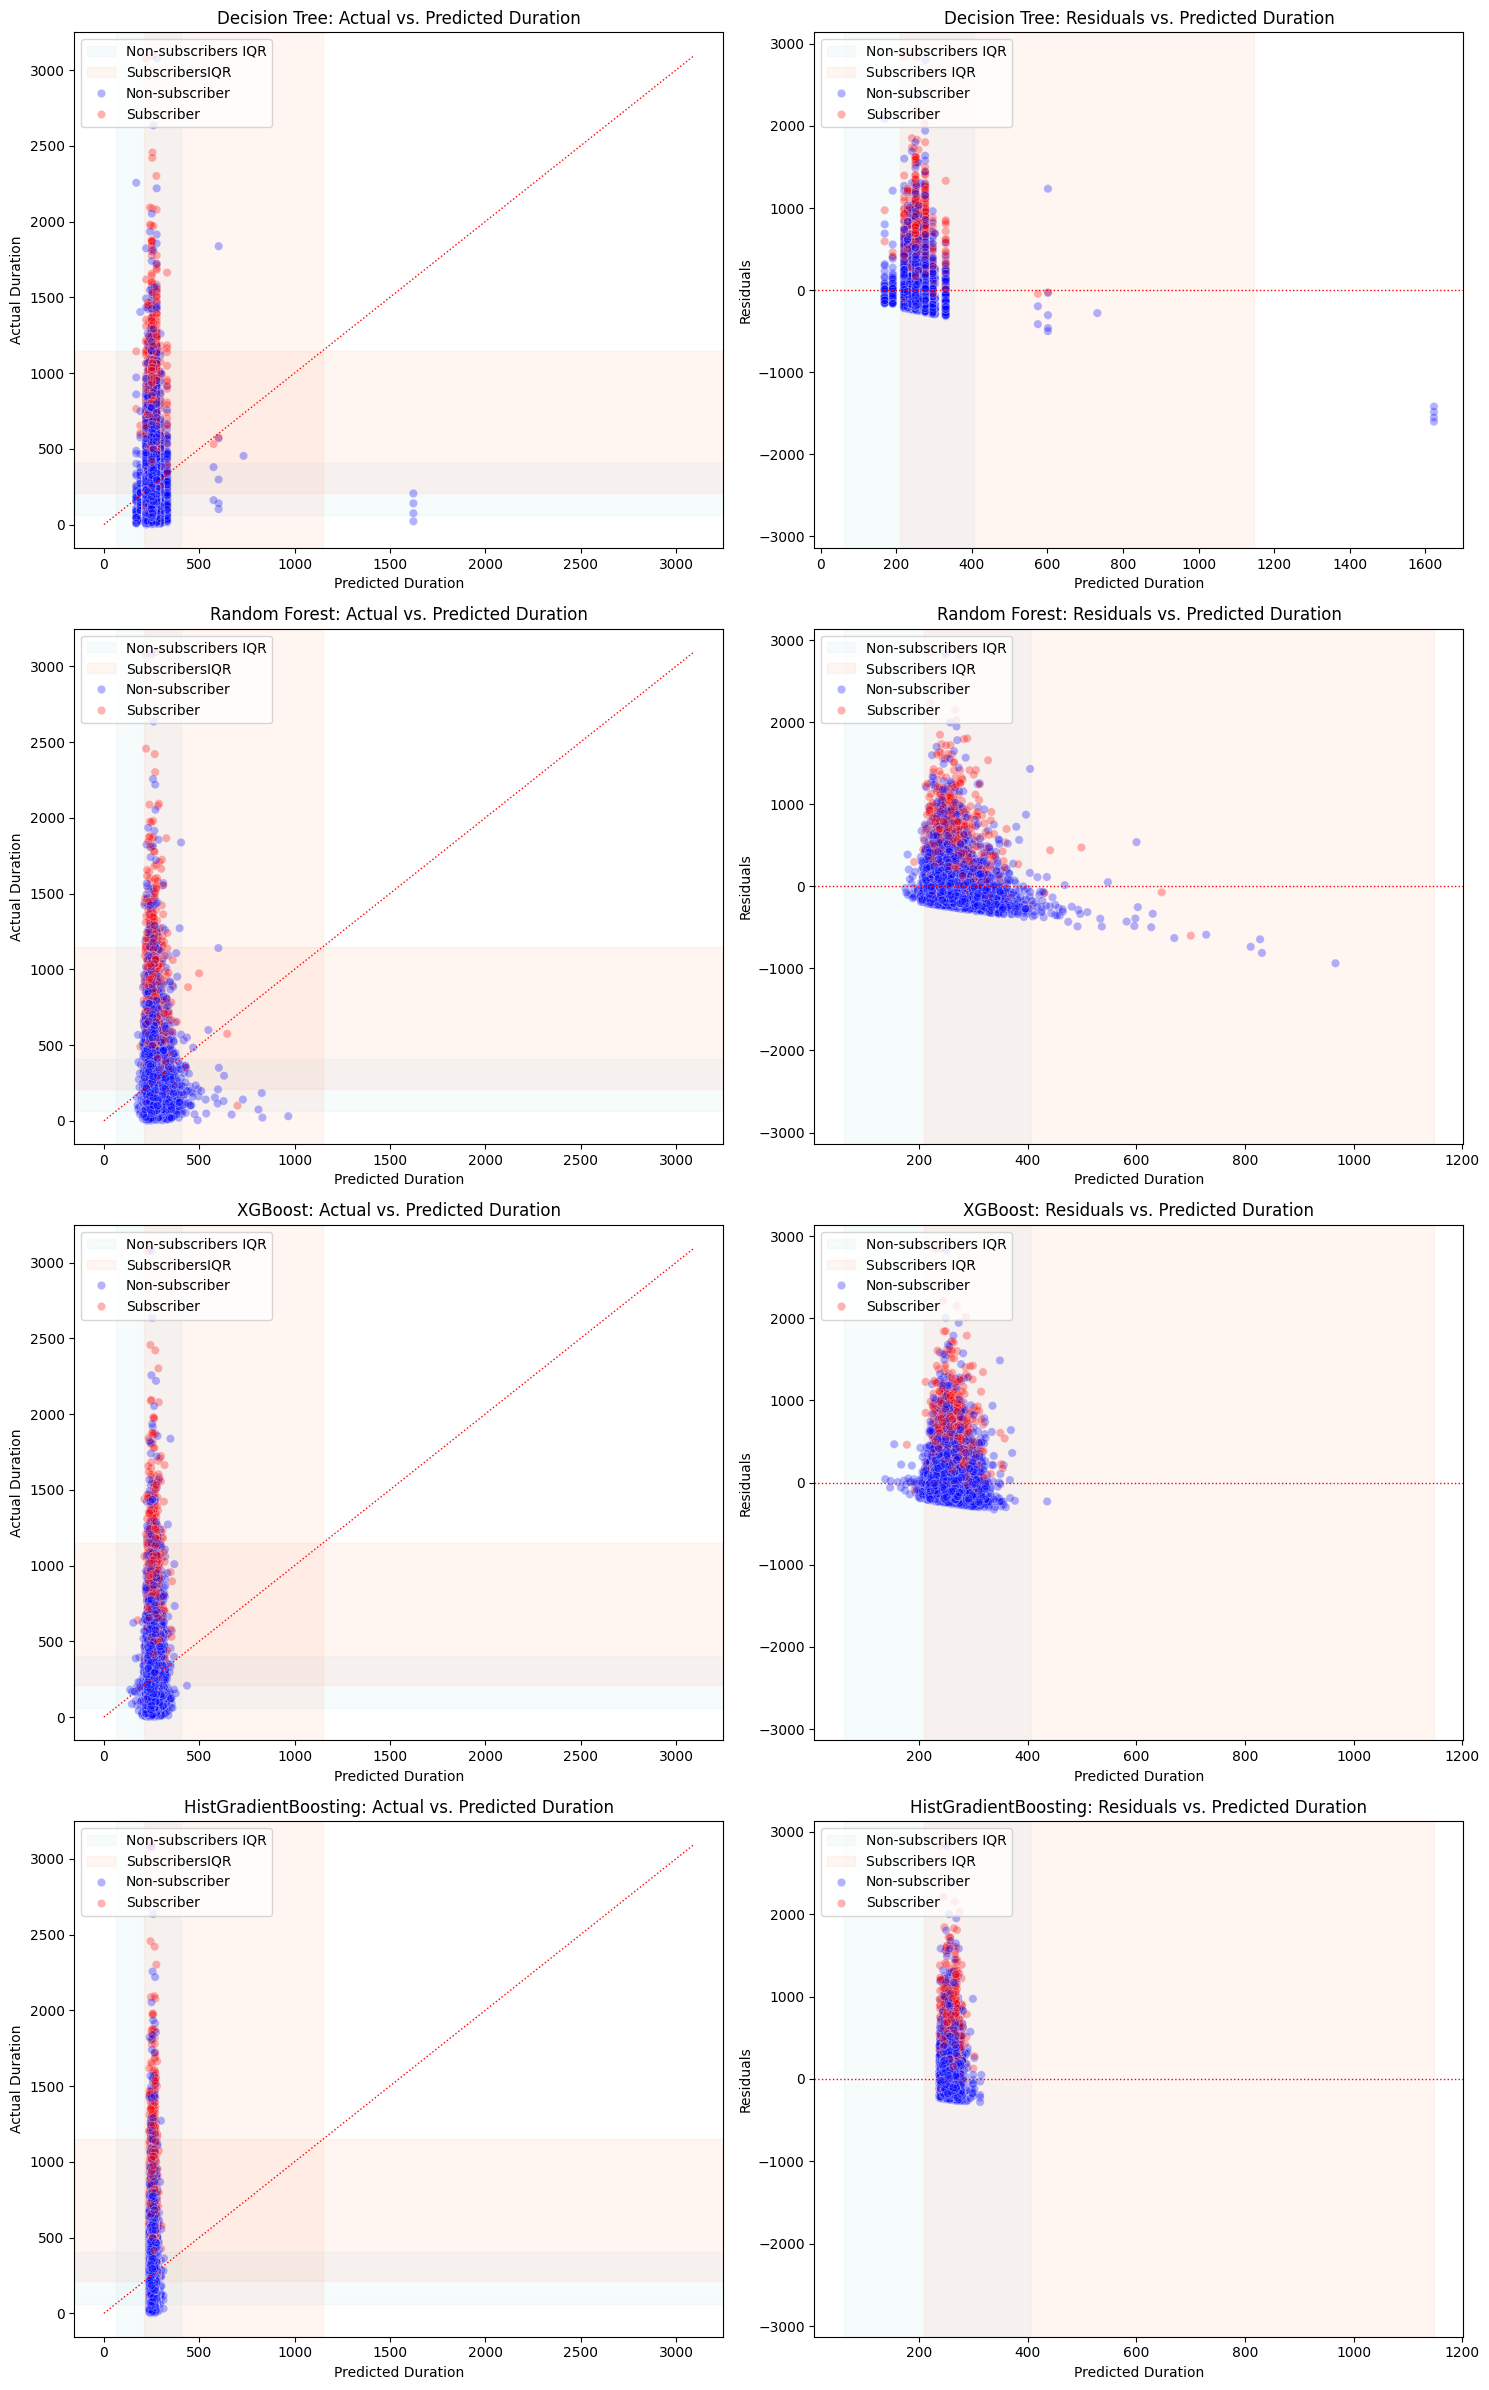

In [32]:
fig, axes = plt.subplots(len(regressors), 2, figsize=(15, 6 * len(regressors)))

# Get y_encoded for the test set once and map to descriptive labels
y_test_subscription_status = df_encoded_onehot.loc[y_test_reg.index, 'y_encoded'].map({0: 'Non-subscriber', 1: 'Subscriber'})

# Define the palette for the scatter plots using descriptive labels
plot_palette = {
    'Non-subscriber': 'b', # Blue for non-subscribers
    'Subscriber': 'r' # Red for subscribers
}

for i, (name, model) in enumerate(regressors.items()):
    # model.fit(X_train_reg, y_train_reg) # Model is already fitted in previous cell
    y_test_pred = model.predict(X_test_reg)
    residuals = y_test_reg - y_test_pred

    # Create a temporary DataFrame for plotting scatter points with hue
    scatter_plot_df = pd.DataFrame({
        'Predicted Duration': y_test_pred,
        'Actual Duration': y_test_reg,
        'Subscription Status': y_test_subscription_status
    })

    # Plot 1: Actual vs. Predicted
    ax0 = axes[i, 0]

    # Highlight non-subscriber range (Octile1-Octile5)
    ax0.axvspan(non_sub_oct1, non_sub_oct5, color='lightblue', alpha=0.1, label='Non-subscribers IQR')
    ax0.axhspan(non_sub_oct1, non_sub_oct5, color='lightblue', alpha=0.1)
    # Highlight subscriber range (Octile1-Octile5)
    ax0.axvspan(sub_oct1, sub_oct5, color='lightsalmon', alpha=0.1, label='SubscribersIQR')
    ax0.axhspan(sub_oct1, sub_oct5, color='lightsalmon', alpha=0.1)

    sns.scatterplot(x='Predicted Duration', y='Actual Duration', hue='Subscription Status', data=scatter_plot_df, ax=ax0, alpha=0.3, palette=plot_palette)
    ax0.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r:', lw=1)
    ax0.set_title(f'{name}: Actual vs. Predicted Duration')
    ax0.set_xlabel('Predicted Duration')
    ax0.set_ylabel('Actual Duration')
    ax0.legend(loc='upper left')

    # Plot 2: Residuals vs. Predicted
    ax1 = axes[i, 1]

    # Highlight non-subscriber range (oct1-Octile5) on predicted axis
    ax1.axvspan(non_sub_oct1, non_sub_oct5, color='lightblue', alpha=0.1, label='Non-subscribers IQR')
    # Highlight subscriber range (oct1-Octile5) on predicted axis
    ax1.axvspan(sub_oct1, sub_oct5, color='lightsalmon', alpha=0.1, label='Subscribers IQR')

    sns.scatterplot(x='Predicted Duration', y=residuals, hue='Subscription Status', data=scatter_plot_df, ax=ax1, alpha=0.3, palette=plot_palette)
    ax1.axhline(y=0, color='r', linestyle=':', lw=1)
    ax1.set_title(f'{name}: Residuals vs. Predicted Duration')
    ax1.set_xlabel('Predicted Duration')
    ax1.set_ylabel('Residuals')
    ax1.legend(loc='upper left')

    # Set y-axis limits for residuals to be symmetric around 0
    max_abs_residual = np.max(np.abs(residuals))
    ax1.set_ylim(-max_abs_residual * 1.1, max_abs_residual * 1.1) # Add some padding

plt.tight_layout()
plt.show()

In [33]:
#Repeat for log regression target
# Split data into training and testing sets
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_stage0, y_regression_log, test_size=0.3, random_state=seed)

# Printt test/train split numbers
print(f"X_train_reg shape: {X_train_reg.shape}")
print(f"X_test_reg shape: {X_test_reg.shape}")

regressors = {
    'Decision Tree': DecisionTreeRegressor(
        max_depth=5,
        random_state=seed
    ),
    'Random Forest': RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        random_state=seed,
        n_jobs=-1
    ),
    'XGBoost': XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=seed,
        objective='reg:squarederror',
        n_jobs=-1
    ),
    'HistGradientBoosting': HistGradientBoostingRegressor(
        max_iter=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=seed
    )
}

results = []

for name, model in regressors.items():
    model.fit(X_train_reg, y_train_reg)
    predictions = model.predict(X_test_reg)

    mae = mean_absolute_error(y_test_reg, predictions)
    rmse = mean_squared_error(y_test_reg, predictions) ** 0.5
    r2 = r2_score(y_test_reg, predictions)

    results.append({
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2,
        'Eg residual [11000]': abs(predictions[11000] - y_test_reg.iloc[11000])
    })

print()
print('Regression Model Performance for Predicting Log(Duration):')
results_df = pd.DataFrame(results).sort_values('RMSE')
print(results_df.round(5))

X_train_reg shape: (28000, 27)
X_test_reg shape: (12000, 27)

Regression Model Performance for Predicting Log(Duration):
                  Model      MAE     RMSE       R²  Eg residual [11000]
2               XGBoost  0.71357  0.93464  0.00657              0.40415
3  HistGradientBoosting  0.71391  0.93512  0.00554              0.42229
1         Random Forest  0.71445  0.93576  0.00418              0.36942
0         Decision Tree  0.71620  0.93789 -0.00036              0.49940


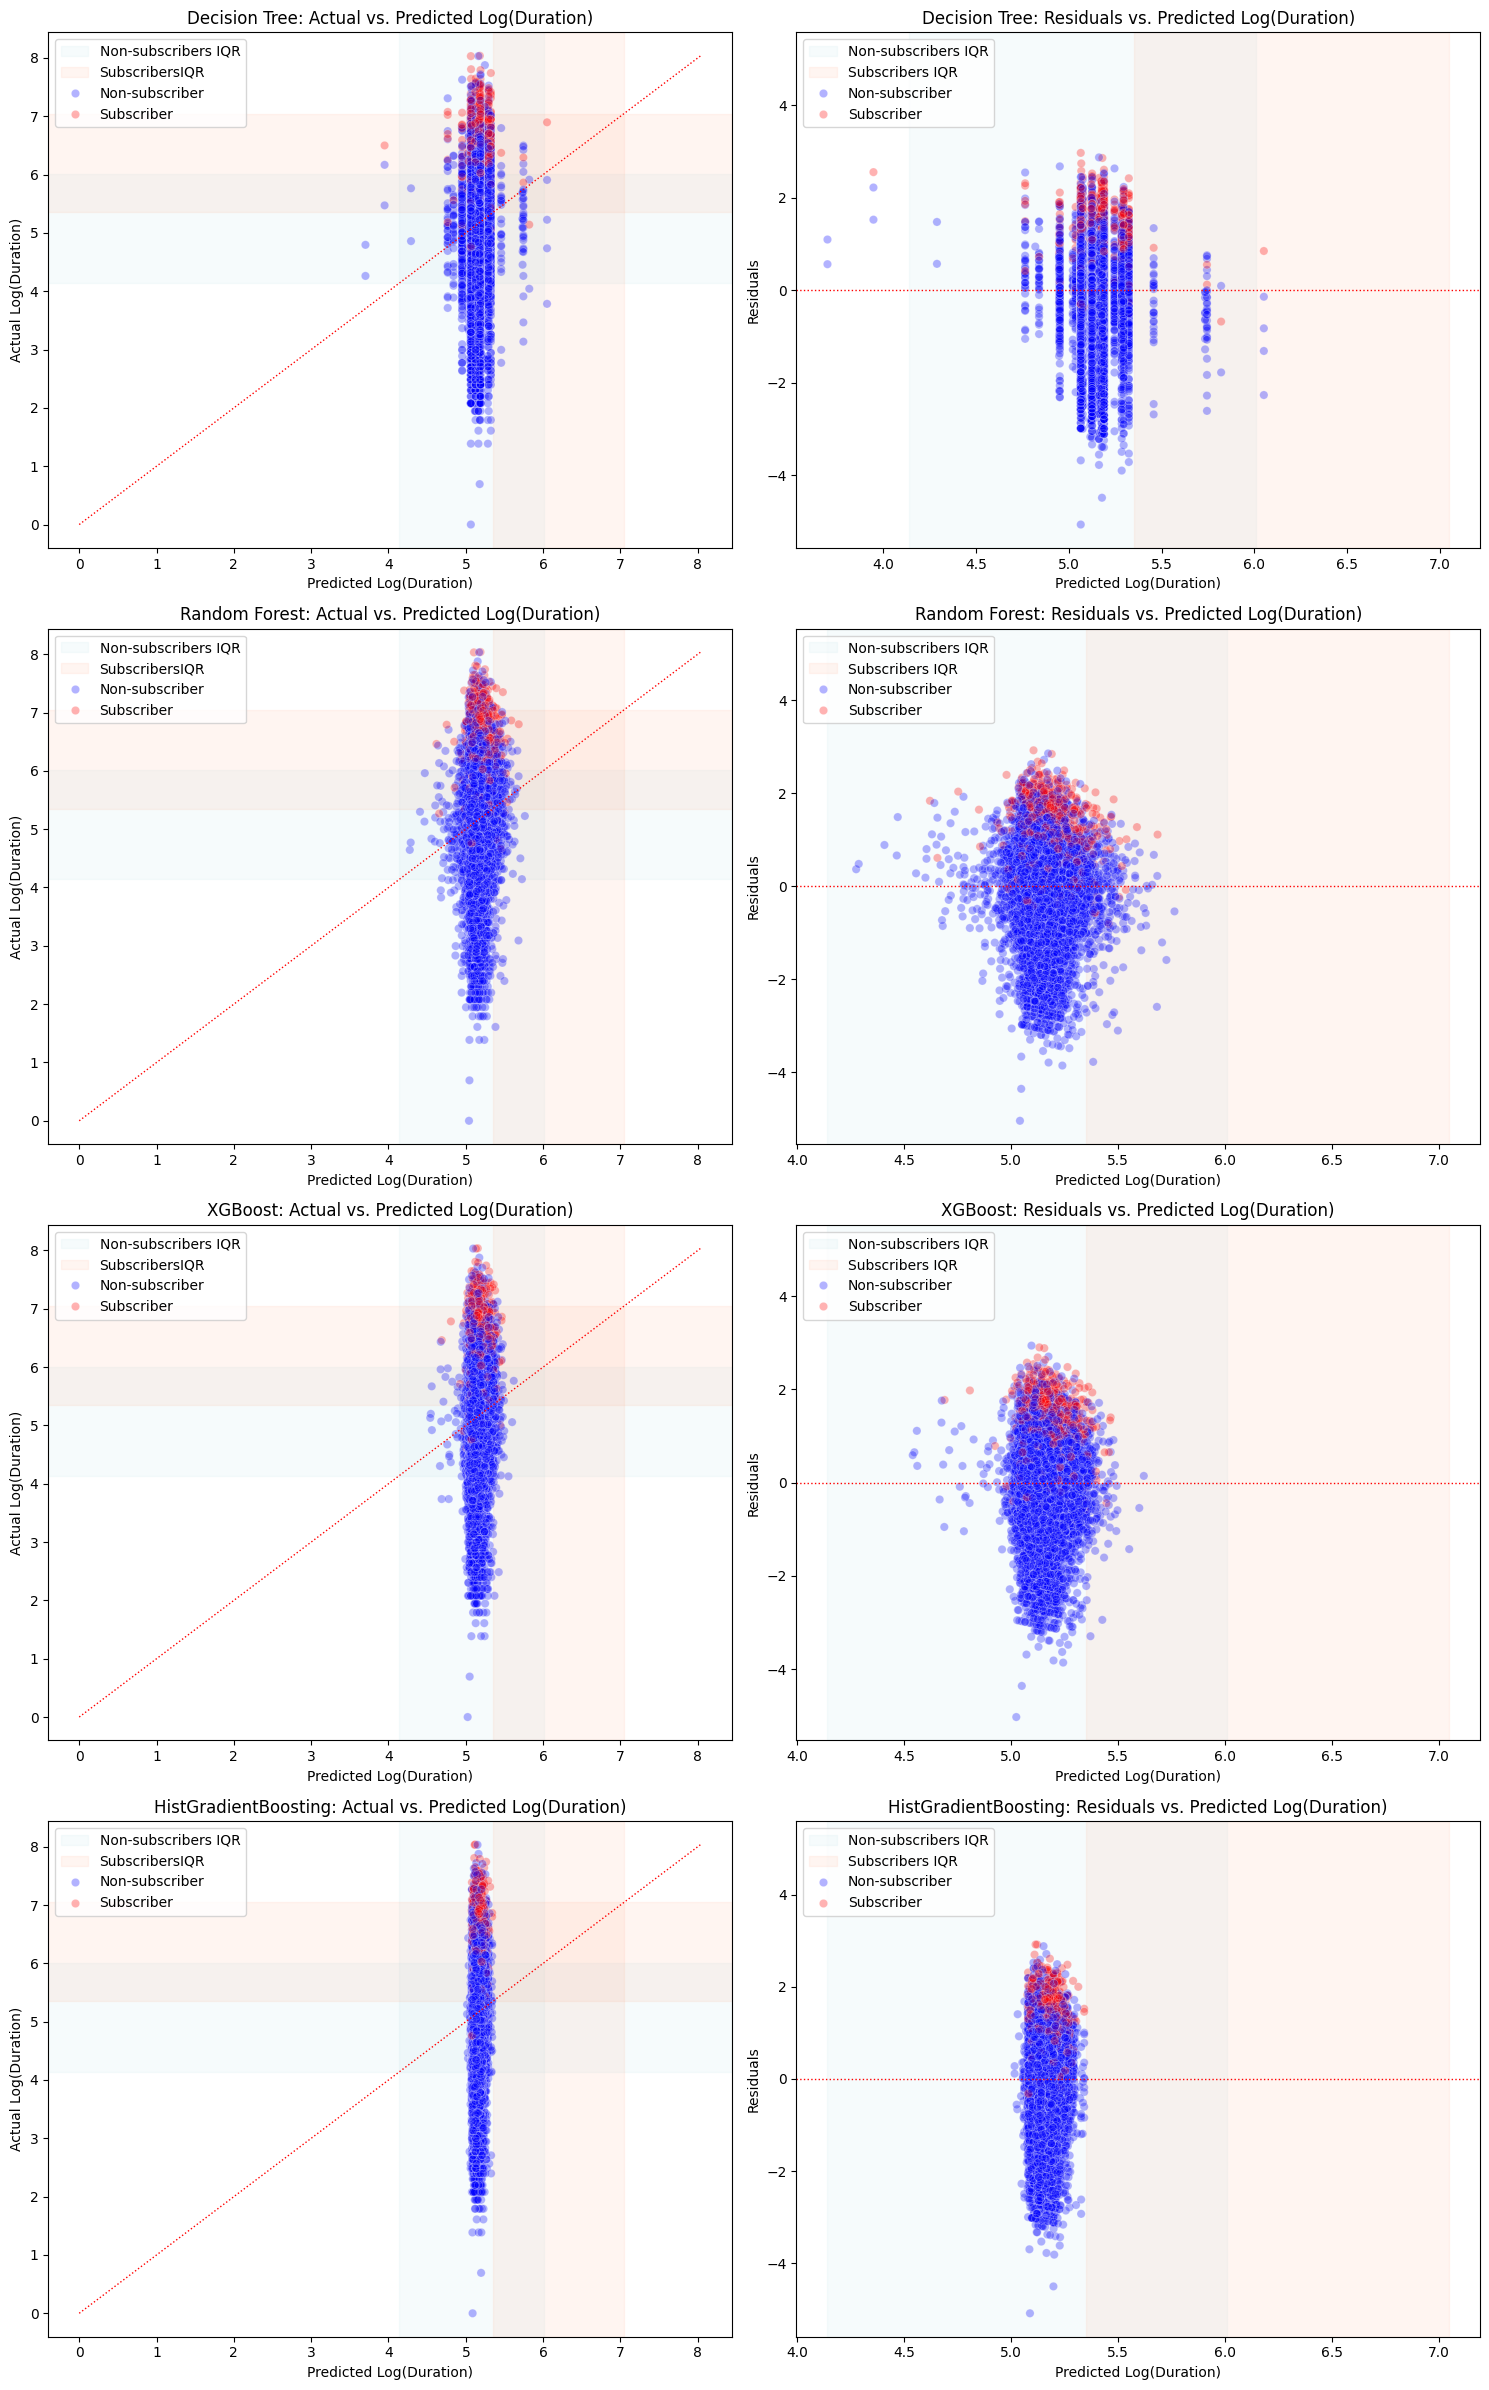

In [34]:

fig, axes = plt.subplots(len(regressors), 2, figsize=(15, 6 * len(regressors)))

# Get y_encoded for the test set once and map to descriptive labels
y_test_subscription_status = df_encoded_onehot.loc[y_test_reg.index, 'y_encoded'].map({0: 'Non-subscriber', 1: 'Subscriber'})

# Define the palette for the scatter plots using descriptive labels
plot_palette = {
    'Non-subscriber': 'b', # Blue for non-subscribers
    'Subscriber': 'r' # Red for subscribers
}

for i, (name, model) in enumerate(regressors.items()):
    # model.fit(X_train_reg, y_train_reg) # Model is already fitted in previous cell
    y_test_pred = model.predict(X_test_reg)
    residuals = y_test_reg - y_test_pred

    # Create a temporary DataFrame for plotting scatter points with hue
    scatter_plot_df = pd.DataFrame({
        'Predicted Log(Duration)': y_test_pred,
        'Actual Log(Duration)': y_test_reg,
        'Subscription Status': y_test_subscription_status
    })

    # Plot 1: Actual vs. Predicted
    ax0 = axes[i, 0]

    # Highlight non-subscriber range (Octile1-Octile5)
    ax0.axvspan(log_non_sub_oct1, log_non_sub_oct5, color='lightblue', alpha=0.1, label='Non-subscribers IQR')
    ax0.axhspan(log_non_sub_oct1, log_non_sub_oct5, color='lightblue', alpha=0.1)
    # Highlight subscriber range (Octile1-Octile5)
    ax0.axvspan(log_sub_oct1, log_sub_oct5, color='lightsalmon', alpha=0.1, label='SubscribersIQR')
    ax0.axhspan(log_sub_oct1, log_sub_oct5, color='lightsalmon', alpha=0.1)

    sns.scatterplot(x='Predicted Log(Duration)', y='Actual Log(Duration)', hue='Subscription Status', data=scatter_plot_df, ax=ax0, alpha=0.3, palette=plot_palette)
    ax0.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r:', lw=1)
    ax0.set_title(f'{name}: Actual vs. Predicted Log(Duration)')
    ax0.set_xlabel('Predicted Log(Duration)')
    ax0.set_ylabel('Actual Log(Duration)')
    ax0.legend(loc='upper left')

    # Plot 2: Residuals vs. Predicted
    ax1 = axes[i, 1]

    # Highlight non-subscriber range (Octile1-Octile5) on predicted axis
    ax1.axvspan(log_non_sub_oct1, log_non_sub_oct5, color='lightblue', alpha=0.1, label='Non-subscribers IQR')
    # Highlight subscriber range (Octile1-Octile5) on predicted axis
    ax1.axvspan(log_sub_oct1, log_sub_oct5, color='lightsalmon', alpha=0.1, label='Subscribers IQR')

    sns.scatterplot(x='Predicted Log(Duration)', y=residuals, hue='Subscription Status', data=scatter_plot_df, ax=ax1, alpha=0.3, palette=plot_palette)
    ax1.axhline(y=0, color='r', linestyle=':', lw=1)
    ax1.set_title(f'{name}: Residuals vs. Predicted Log(Duration)')
    ax1.set_xlabel('Predicted Log(Duration)')
    ax1.set_ylabel('Residuals')
    ax1.legend(loc='upper left')

    # Set y-axis limits for residuals to be symmetric around 0
    max_abs_residual = np.max(np.abs(residuals))
    ax1.set_ylim(-max_abs_residual * 1.1, max_abs_residual * 1.1) # Add some padding

plt.tight_layout()
plt.show()

### EDA on predicted high log(duration) customers

In [75]:
# Split data into training and testing sets
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_stage0, y_regression_log, test_size=0.3, random_state=seed)

# Define the octile ranges for subscribers (Log Duration)
log_sub_oct1, log_sub_median, log_sub_oct5 = df_encoded_onehot[df_encoded_onehot['y_encoded'] == 1]['log_duration'].quantile([0.125, 0.5, 0.875])


# run random forest on testing data
rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=seed, n_jobs=-1)
rf.fit(X_train_reg, y_train_reg)

y_test_pred = rf.predict(X_test_reg)
residuals = y_test_reg - y_test_pred

# write the y_test_pred and residuals to the dataframe
prediction_df = df_encoded_onehot.copy()
prediction_df.loc[y_test_reg.index, 'predicted_log_duration'] = y_test_pred
prediction_df.loc[y_test_reg.index, 'residuals'] = residuals

# remove rows without a predicted log duration
prediction_df = prediction_df.dropna(subset=['predicted_log_duration'])


# write the y_test_pred and residuals to the dataframe
prediction_cat_df = df_encoded.copy()
prediction_cat_df.loc[y_test_reg.index, 'predicted_log_duration'] = y_test_pred
prediction_cat_df.loc[y_test_reg.index, 'residuals'] = residuals

# remove rows without a predicted log duration
prediction_cat_df = prediction_cat_df.dropna(subset=['predicted_log_duration'])

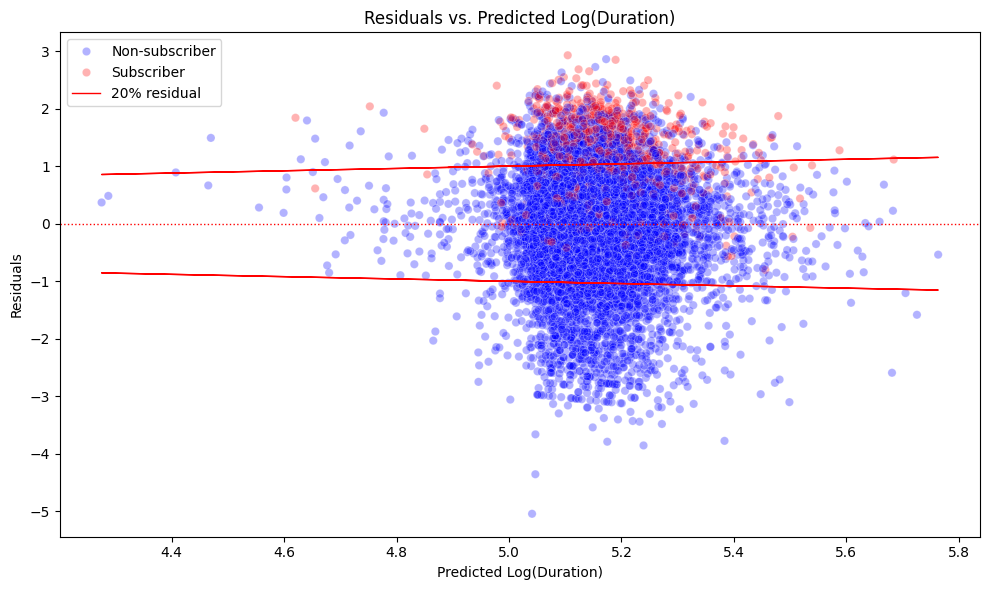

In [76]:
# plot residuals
fig, ax = plt.subplots(figsize=(10, 6))
#sns.scatterplot(x=y_test_reg, y=residuals, ax=ax)
sns.scatterplot(x=y_test_pred, y=residuals, ax=ax, hue=df_encoded_onehot.loc[y_test_reg.index, 'y_encoded'].map({0: 'Non-subscriber', 1: 'Subscriber'}), alpha=0.3, palette={'Non-subscriber': 'b', 'Subscriber': 'r'})

ax.axhline(y=0, color='r', linestyle=':', lw=1)
ax.set_title('Residuals vs. Predicted Log(Duration)')
ax.set_xlabel('Predicted Log(Duration)')
ax.set_ylabel('Residuals')

# calculate the max and min range of 20% residuals
max_residuals = y_test_pred * 0.2
min_residuals = y_test_pred * (-0.2)

# plot the lines of the max and min
ax.plot(y_test_pred, max_residuals, color='r', linestyle='-', lw=1, label='20% residual')
ax.plot(y_test_pred, min_residuals, color='r', linestyle='-', lw=1)

ax.legend(loc='upper left')

plt.tight_layout()
plt.show()


In [77]:
# filter out high residual data
high_resid_df = prediction_df[(prediction_df['residuals'] > max_residuals) | (prediction_df['residuals'] < min_residuals)]
high_resid_df.info()

high_resid_cat_df = prediction_cat_df[(prediction_cat_df['residuals'] > max_residuals) | (prediction_cat_df['residuals'] < min_residuals)]
high_resid_cat_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2876 entries, 19 to 39991
Data columns (total 48 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     2876 non-null   int64  
 1   balance                 2876 non-null   int64  
 2   day                     2876 non-null   int64  
 3   duration                2876 non-null   int64  
 4   campaign                2876 non-null   int64  
 5   y_encoded               2876 non-null   int64  
 6   job_admin               2876 non-null   int64  
 7   job_blue-collar         2876 non-null   int64  
 8   job_entrepreneur        2876 non-null   int64  
 9   job_housemaid           2876 non-null   int64  
 10  job_management          2876 non-null   int64  
 11  job_retired             2876 non-null   int64  
 12  job_self-employed       2876 non-null   int64  
 13  job_services            2876 non-null   int64  
 14  job_student             2876 non-null   int

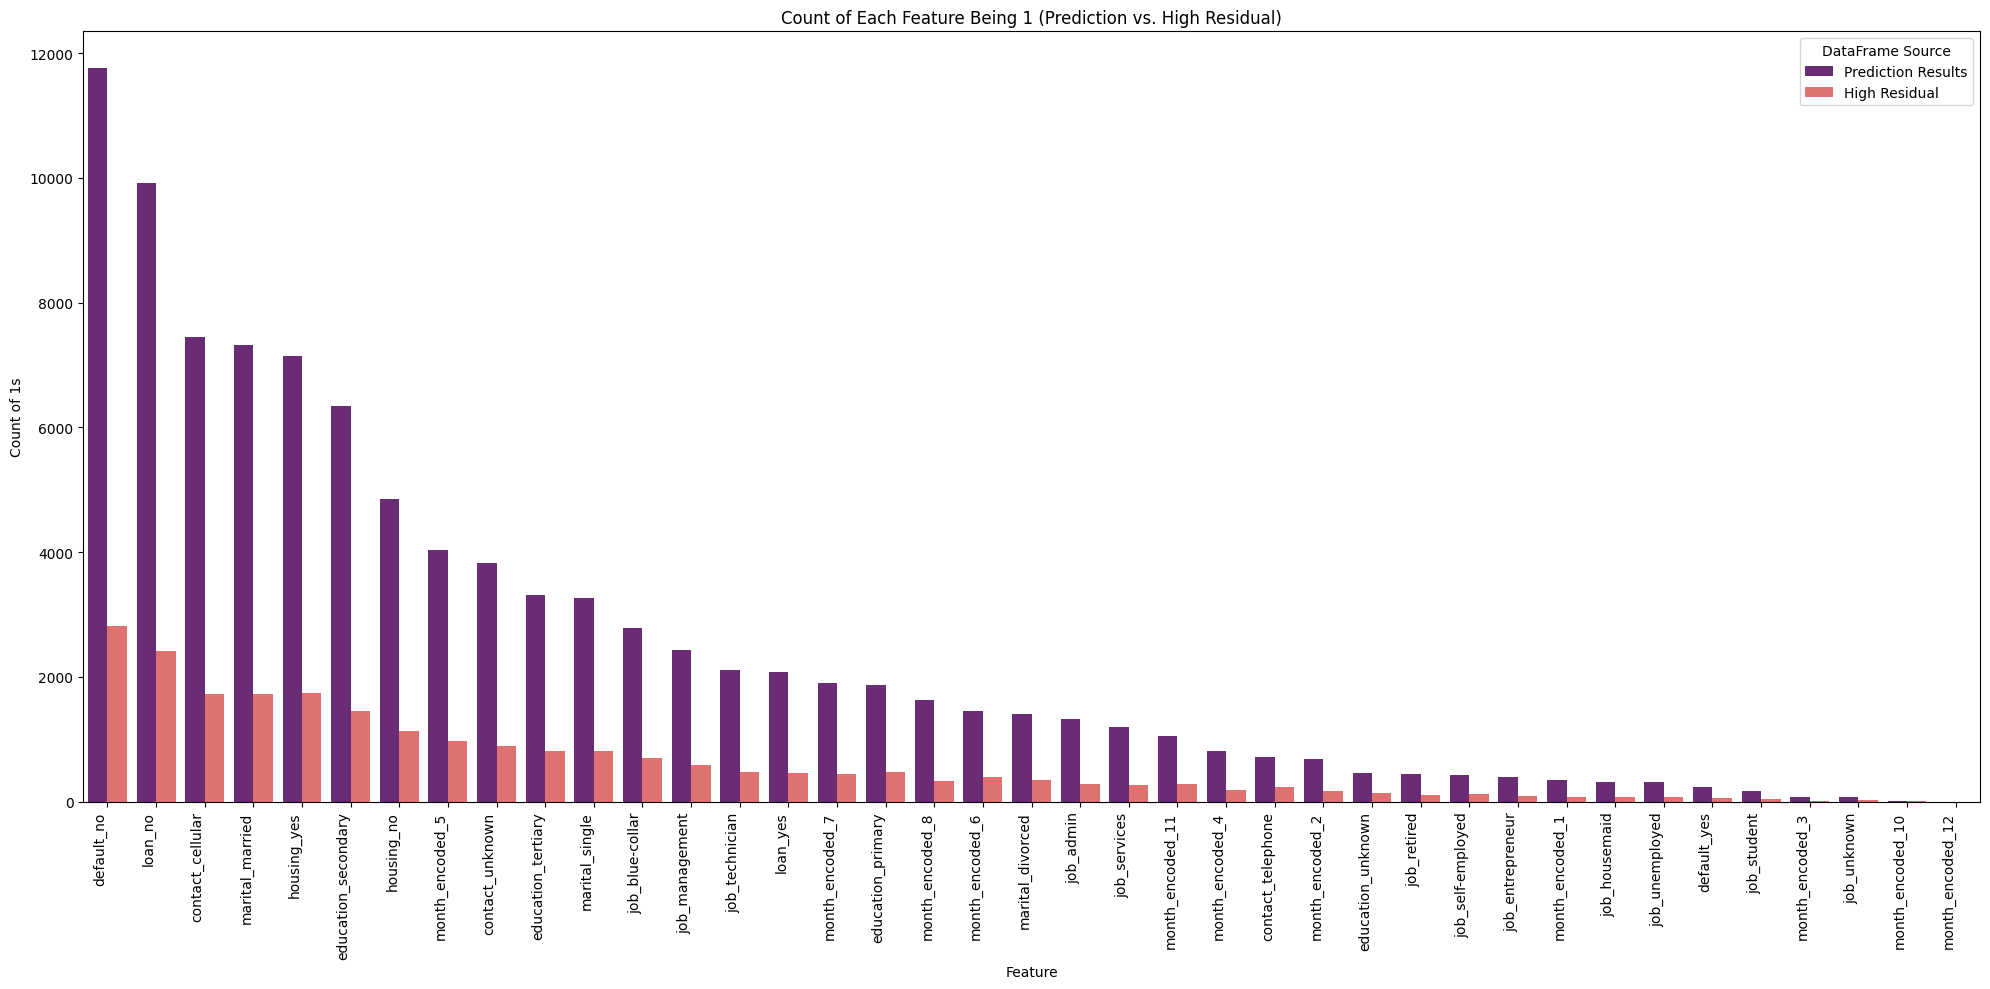

In [78]:
# Identify one-hot encoded columns by excluding known numerical and target columns
# The exclude_cols from previous steps is sufficient.
exclude_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'y_encoded', 'log_duration', 'predicted_log_duration', 'residuals']
onehot_cols = [col for col in df_encoded_onehot.columns if col not in exclude_cols]

# Calculate counts for prediction_df
onehot_counts_prediction = {}
for col in onehot_cols:
    if col in prediction_df.columns:
        onehot_counts_prediction[col] = prediction_df[col].sum()

# Calculate counts for high_resid_df
onehot_counts_high_resid = {}
for col in onehot_cols:
    if col in high_resid_df.columns:
        onehot_counts_high_resid[col] = high_resid_df[col].sum()

# Convert to Series for easier handling
onehot_series_prediction = pd.Series(onehot_counts_prediction)
onehot_series_high_resid = pd.Series(onehot_counts_high_resid)

# Prepare data for clustered bar chart
df_plot_prediction = pd.DataFrame({'Feature': onehot_series_prediction.index, 'Count': onehot_series_prediction.values, 'DataFrame': 'Prediction Results'})
df_plot_high_resid = pd.DataFrame({'Feature': onehot_series_high_resid.index, 'Count': onehot_series_high_resid.values, 'DataFrame': 'High Residual'})

# Concatenate the two DataFrames
combined_df = pd.concat([df_plot_prediction, df_plot_high_resid])

# Sort features by the total count from prediction_df for consistent ordering
sorted_features = onehot_series_prediction.sort_values(ascending=False).index.tolist()
combined_df['Feature'] = pd.Categorical(combined_df['Feature'], categories=sorted_features, ordered=True)

# Plotting the clustered bar chart
plt.figure(figsize=(20, 10))
sns.barplot(x='Feature', y='Count', hue='DataFrame', data=combined_df, palette='magma')
plt.xticks(rotation=90, ha='right')
plt.xlabel('Feature')
plt.ylabel('Count of 1s')
plt.title('Count of Each Feature Being 1 (Prediction vs. High Residual)')
plt.legend(title='DataFrame Source')
plt.tight_layout()
plt.show()

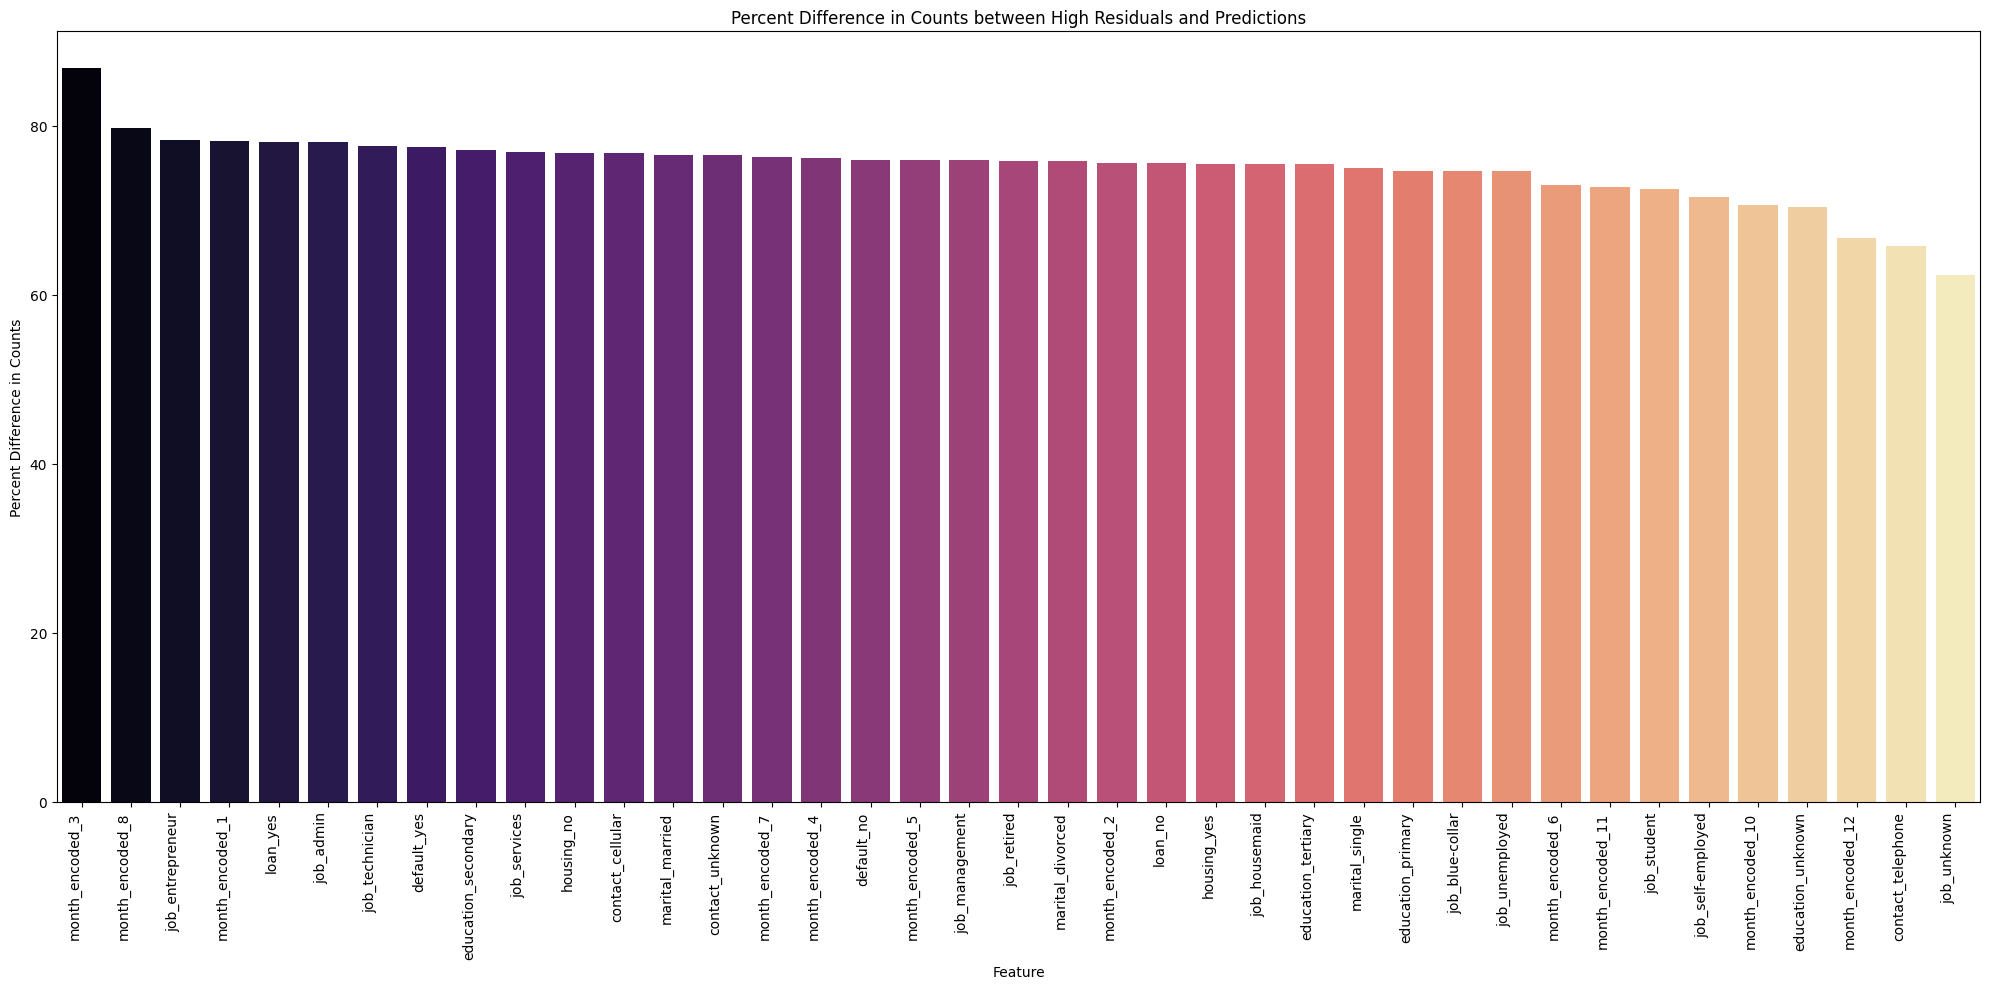

In [81]:
# calculate the difference in counts between high residuals and predictions
diff_counts = ((onehot_series_prediction - onehot_series_high_resid)/onehot_series_prediction)*100
diff_counts = diff_counts.sort_values(ascending=False)

# plot a bar chart
plt.figure(figsize=(20, 10))
sns.barplot(x=diff_counts.index, y=diff_counts.values, palette='magma')
plt.xticks(rotation=90, ha='right')
plt.xlabel('Feature')
plt.ylabel('Percent Difference in Counts')
plt.title('Percent Difference in Counts between High Residuals and Predictions')
#plt.yscale('log')
plt.tight_layout()
plt.show()

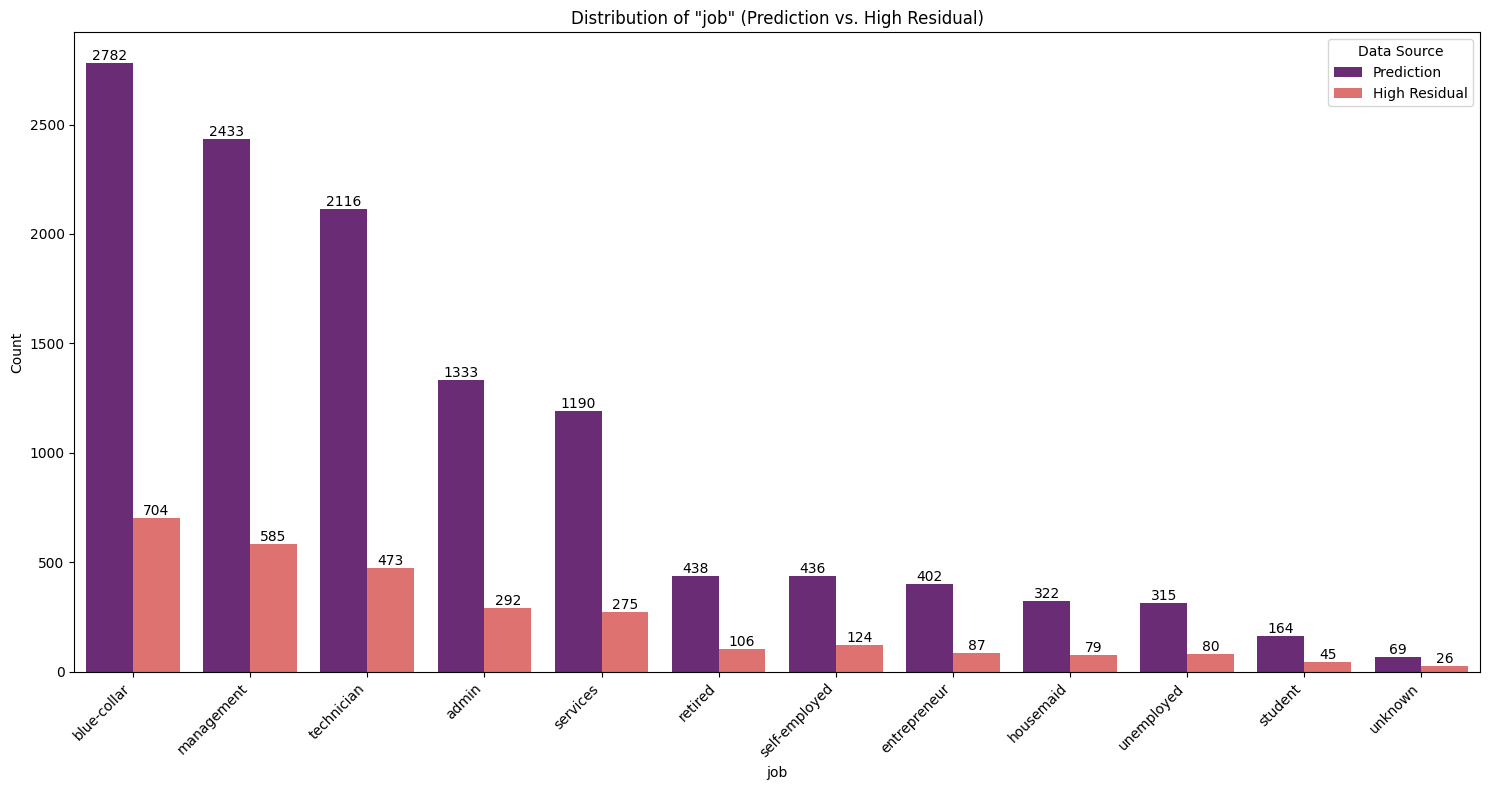

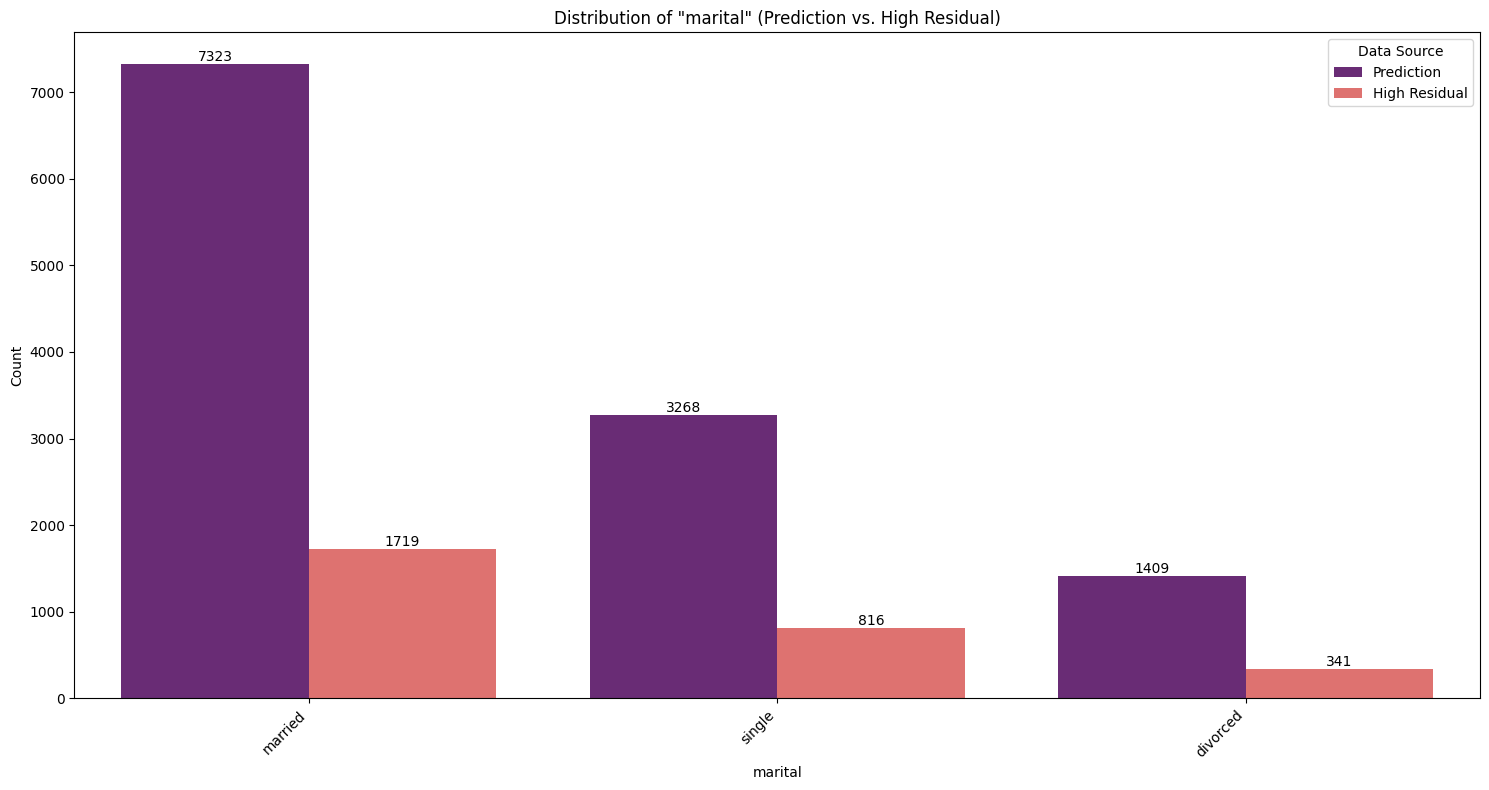

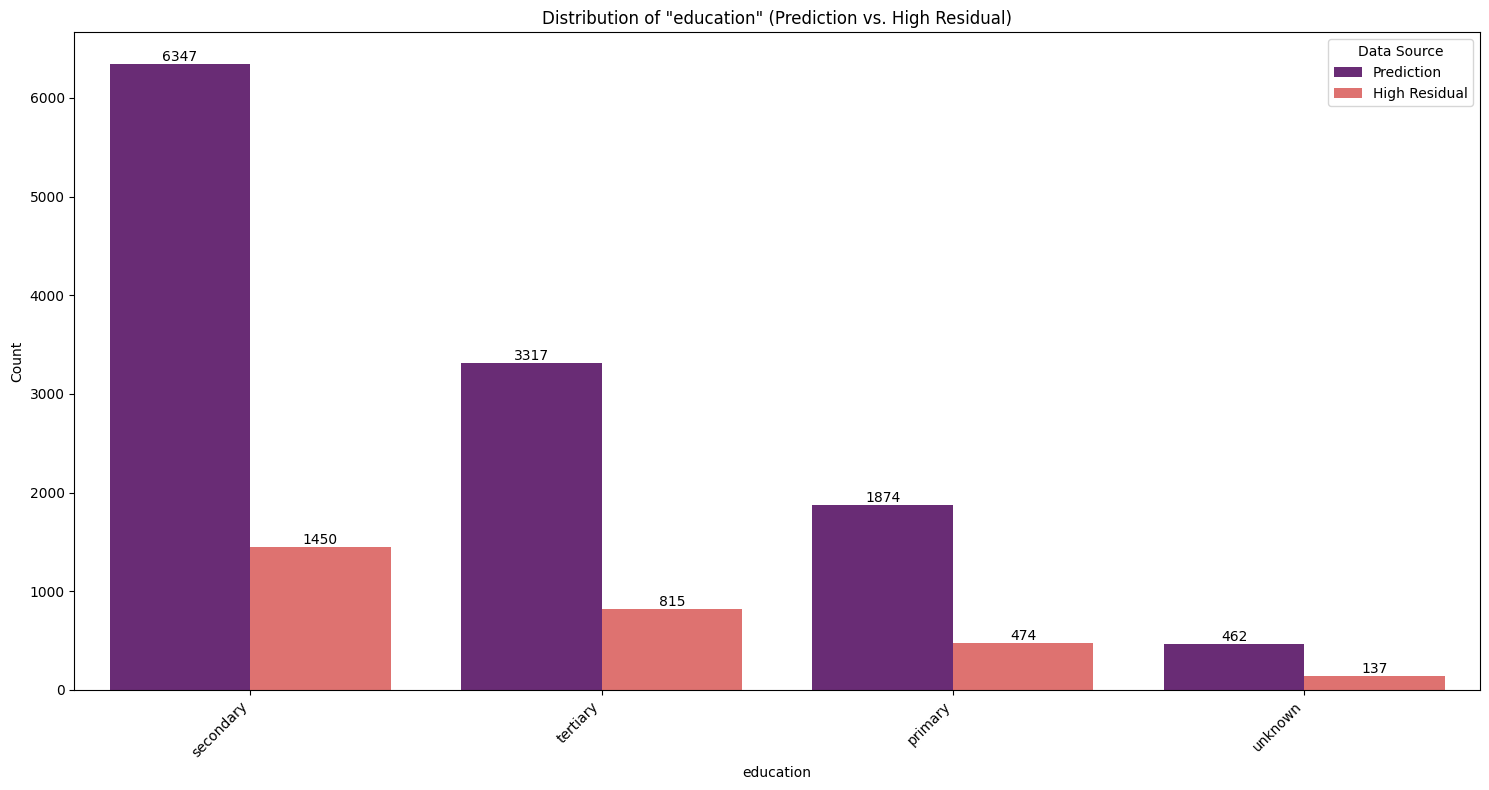

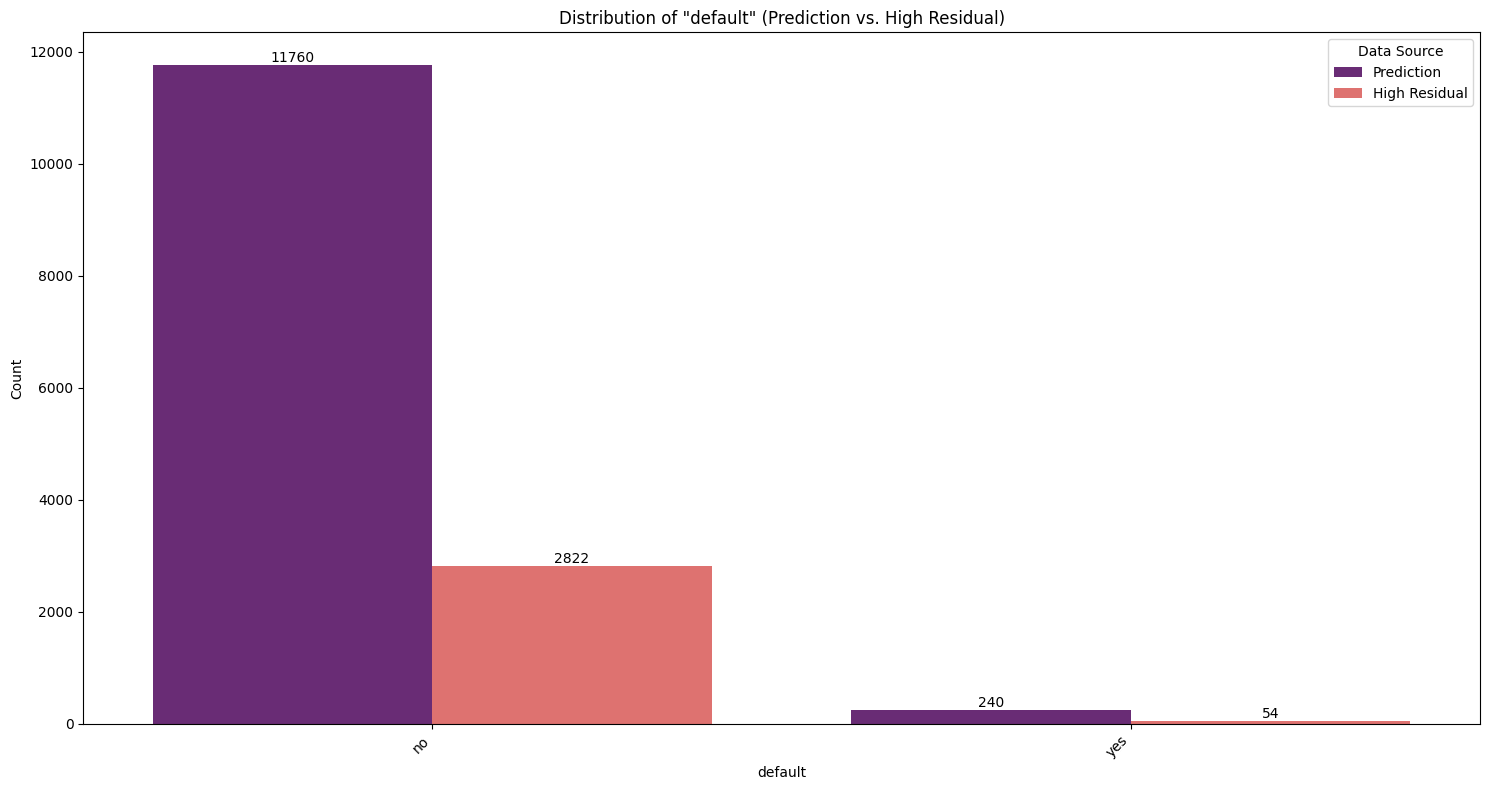

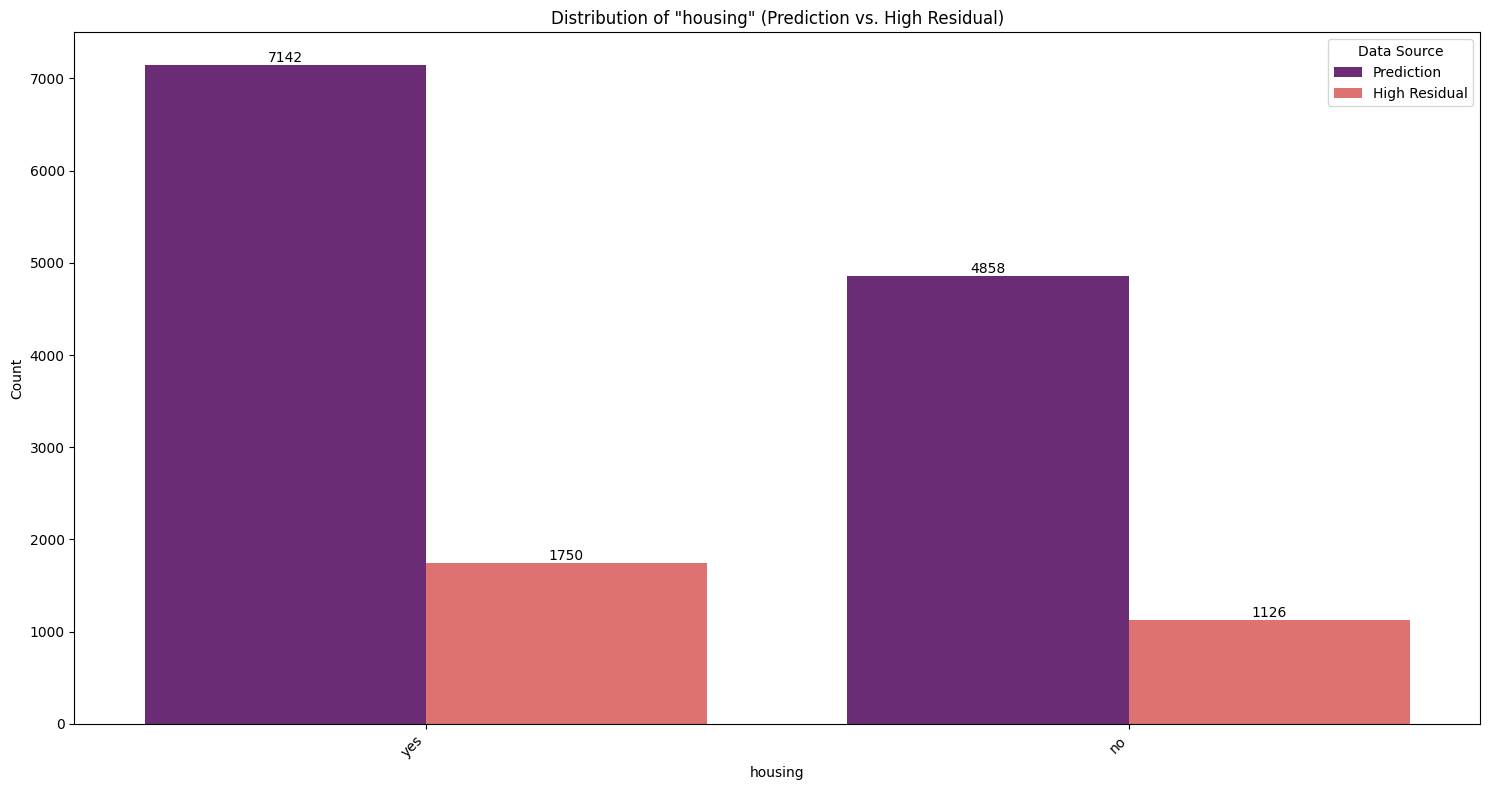

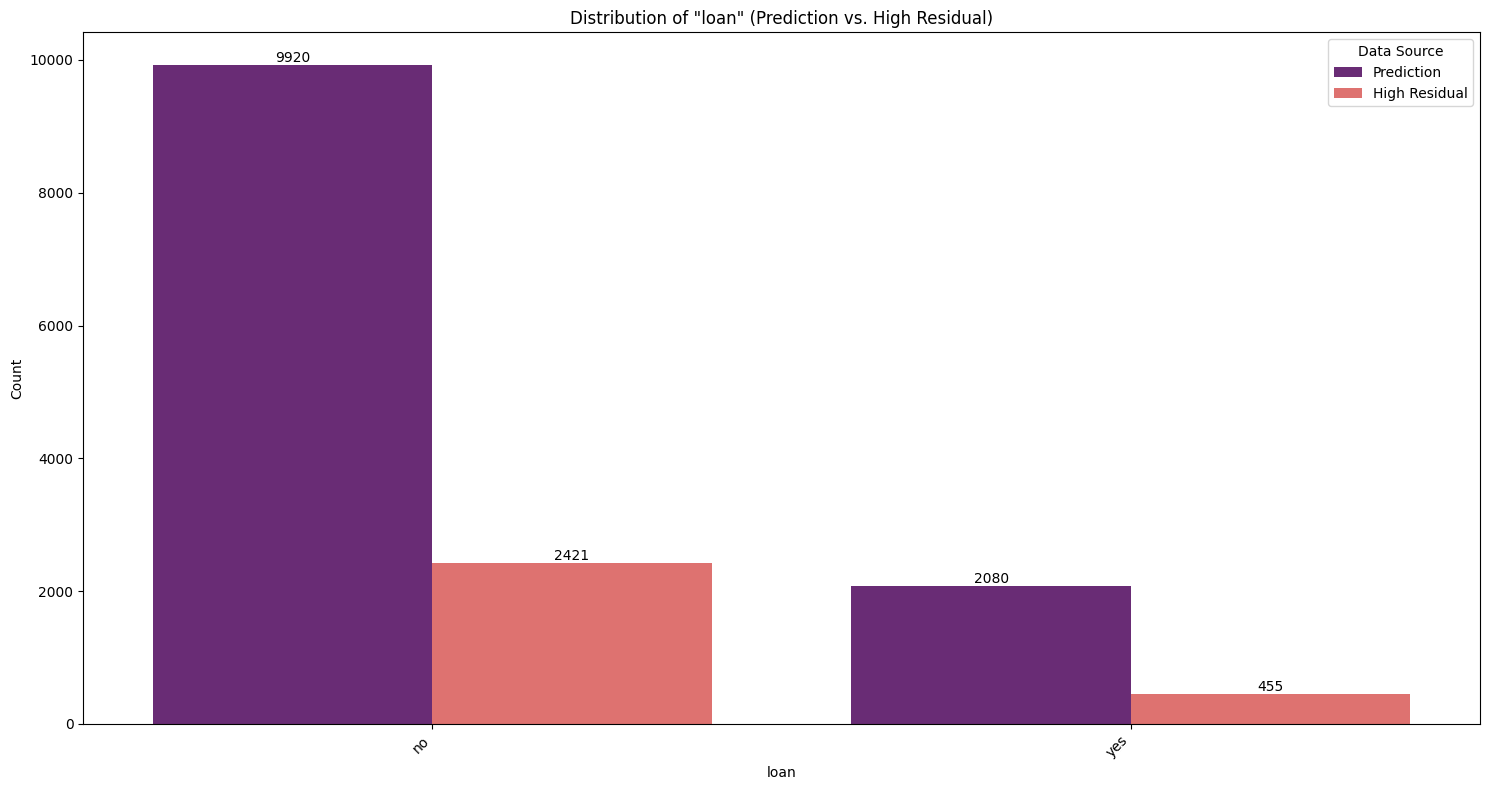

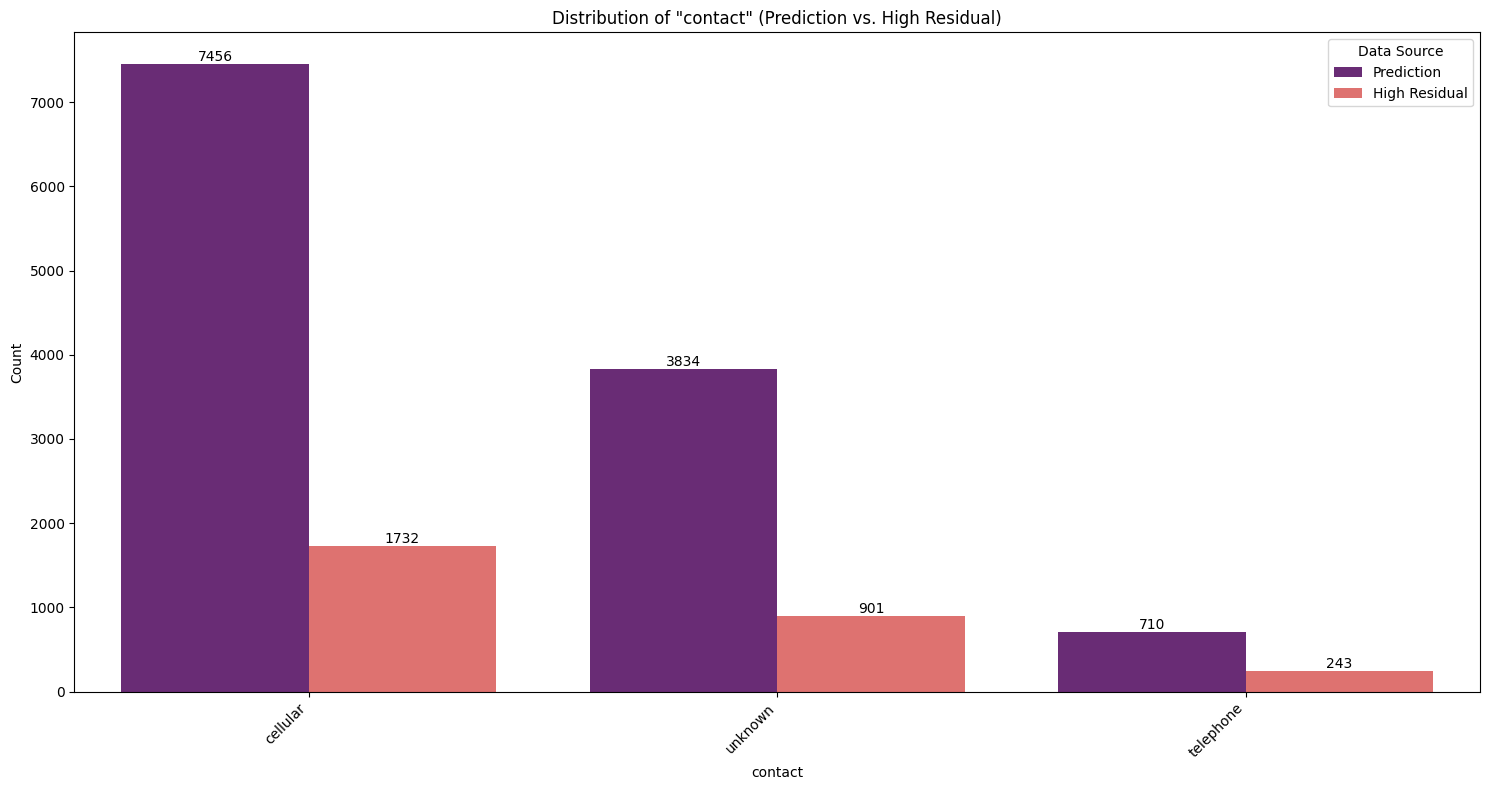

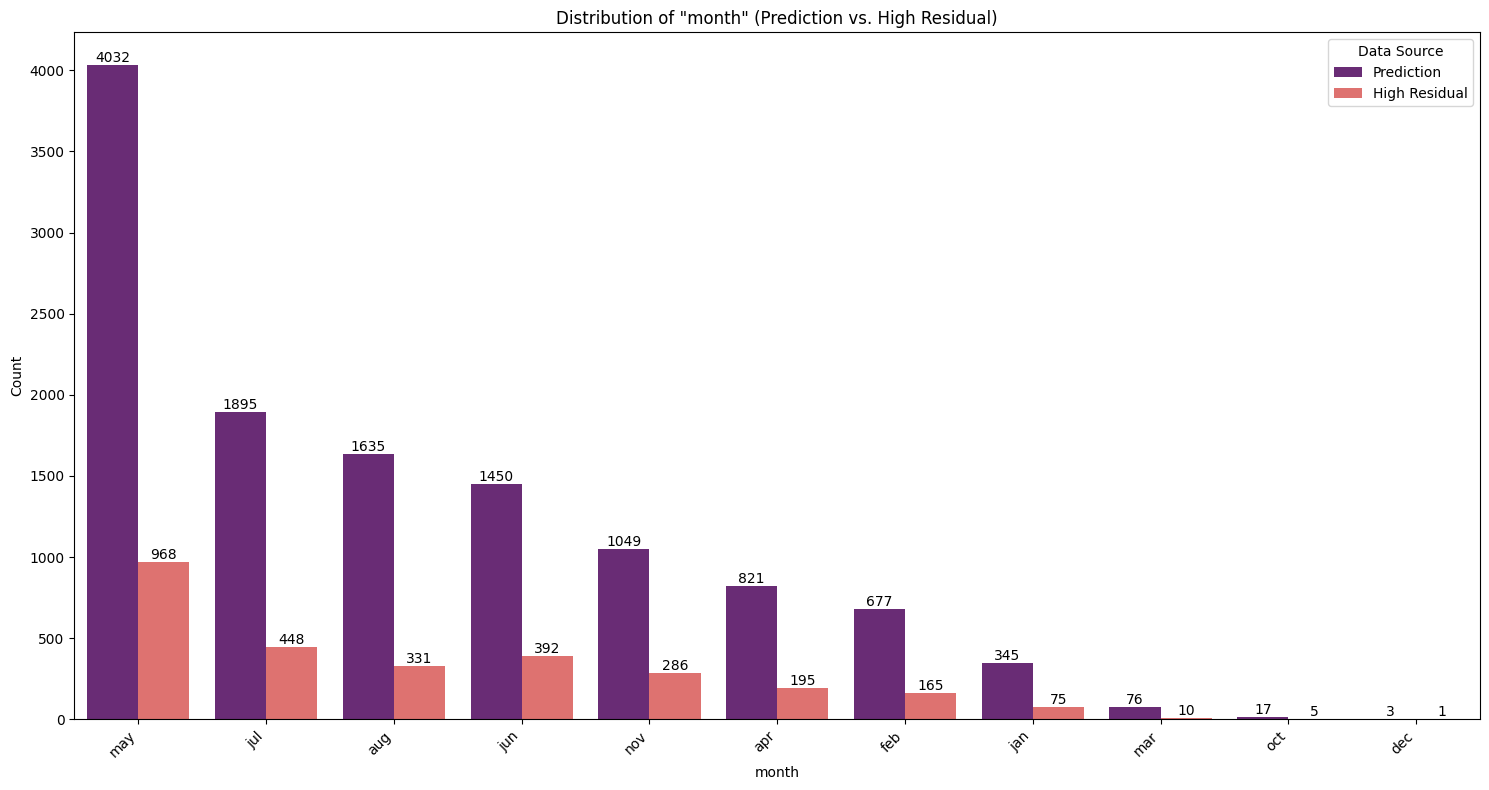

In [84]:
for col in categorical_cols:
    plt.figure(figsize=(15, 8))

    # Get value counts for prediction_cat_df
    counts_prediction = prediction_cat_df[col].value_counts().reset_index()
    counts_prediction.columns = [col, 'Count']
    counts_prediction['DataFrame'] = 'Prediction'

    # Get value counts for high_resid_cat_df
    counts_high_resid = high_resid_cat_df[col].value_counts().reset_index()
    counts_high_resid.columns = [col, 'Count']
    counts_high_resid['DataFrame'] = 'High Residual'

    # Combine the dataframes
    combined_counts_df = pd.concat([counts_prediction, counts_high_resid])

    # Determine the order based on total counts in prediction_cat_df for consistent plotting
    order = prediction_cat_df[col].value_counts().index

    # Plotting the clustered bar chart
    ax = sns.barplot(x=col, y='Count', hue='DataFrame', data=combined_counts_df, order=order, palette='magma')

    plt.title(f'Distribution of "{col}" (Prediction vs. High Residual)')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Data Source')

    # Add total counts at the top of the bars
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', label_type='edge')

    plt.tight_layout()
    plt.show()